# Analisis Model Prediksi Keberhasilan Pengobatan MDR-TB
## Notebook untuk Menghasilkan Figur Publikasi Disertasi

Notebook ini menghasilkan semua figur dan tabel yang dibutuhkan untuk bab Hasil & Pembahasan disertasi.

**Sections:**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Class Imbalance Analysis
4. Model Training & Evaluation
5. Bootstrap 95% Confidence Intervals
6. ROC & Precision-Recall Curves
7. Confusion Matrix Heatmaps
8. Calibration Curves & Brier Scores
9. Feature Importance & Odds Ratio Forest Plot
10. Gini Feature Importance - Decision Tree
11. SHAP Interpretability
12. Nested Cross-Validation
13. Sensitivity Analysis
14. Export All Figures


In [1]:
# ============================
# 1. Setup & Data Loading
# ============================
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Publication-quality settings
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 6),
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})
sns.set_style('whitegrid')
sns.set_palette('Set2')

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

from preprocessing import DataPreprocessor
from training import ModelTrainer
from evaluation import ModelEvaluator
from interpretability import (
    get_all_interpretability, get_class_distribution,
    get_lr_odds_ratios, get_tree_feature_importance,
    get_permutation_importance_data
)

preprocessor = DataPreprocessor()

print("Setup complete.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

Setup complete.
Project root: /Users/rada/Downloads/kak sri/ml-service
Figures will be saved to: /Users/rada/Downloads/kak sri/ml-service/notebooks/figures


In [2]:
# Load data dari MySQL (sumber data yang sama dengan web)
import pymysql

DB_CONFIG = {
    'host': 'localhost',
    'port': 3306,
    'user': 'root',
    'password': 'root',
    'database': 'laravel_mdr',
}

# Column mapping: database (lowercase) -> preprocessor format
COLUMN_MAPPING = {
    'usia': 'Usia',
    'ket_usia': 'Ket.Usia',
    'jenis_kelamin': 'Jenis Kelamin',
    'status_bekerja': 'Status Bekerja',
    'bb': 'BB',
    'tb': 'TB',
    'imt': 'IMT',
    'status_gizi': 'Status Gizi',
    'status_merokok': 'Status Merokok',
    'pemeriksaan_kontak': 'Pemeriksaan Kontak',
    'riwayat_dm': 'Riwayat_DM',
    'riwayat_hiv': 'Riwayat_HIV',
    'komorbiditas': 'Komorbiditas',
    'kepatuhan_minum_obat': 'Kepatuhan Minum Obat',
    'efek_samping_obat': 'Efek Samping Obat',
    'keterangan_efek_samping': 'Keterangan Efek Samping',
    'riwayat_pengobatan': 'Riwayat Pengobatan Sebelumnya',
    'panduan_pengobatan': 'Panduan Pengobatan',
    'keberhasilan_pengobatan': 'Keberhasilan Pengobatan',
}

conn = pymysql.connect(**DB_CONFIG)
query = "SELECT * FROM training_data"
df_raw = pd.read_sql(query, conn)
conn.close()

# Rename columns to match preprocessor format
df_raw = df_raw.rename(columns=COLUMN_MAPPING)

# Drop database-only columns (id, timestamps)
cols_to_drop = [c for c in ['id', 'created_at', 'updated_at'] if c in df_raw.columns]
df_raw = df_raw.drop(columns=cols_to_drop)

print(f"Data loaded from MySQL database: laravel_mdr")
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Data loaded from MySQL database: laravel_mdr
Raw data shape: (175, 19)
Columns: ['Usia', 'Ket.Usia', 'Jenis Kelamin', 'Status Bekerja', 'BB', 'TB', 'IMT', 'Status Gizi', 'Status Merokok', 'Pemeriksaan Kontak', 'Riwayat_DM', 'Riwayat_HIV', 'Komorbiditas', 'Kepatuhan Minum Obat', 'Efek Samping Obat', 'Keterangan Efek Samping', 'Riwayat Pengobatan Sebelumnya', 'Panduan Pengobatan', 'Keberhasilan Pengobatan']


,Usia,Ket.Usia,Jenis Kelamin,Status Bekerja,BB,TB,IMT,Status Gizi,Status Merokok,Pemeriksaan Kontak,Riwayat_DM,Riwayat_HIV,Komorbiditas,Kepatuhan Minum Obat,Efek Samping Obat,Keterangan Efek Samping,Riwayat Pengobatan Sebelumnya,Panduan Pengobatan,Keberhasilan Pengobatan
0,Usia Produktif,48,Perempuan,Tidak Bekerja,47.0,156.0,20.5,Gizi Normal,Tidak Merokok,Ya,Tidak,Tidak,Tidak Ada,Patuh,Ada Keluhan,"Muntah ringan, nafsu makan berkurang, alergi k...",Kasus Lama,Jangka Pendek,Berhasil
1,Usia Produktif,20,Perempuan,Bekerja,49.0,149.0,22.0,Gizi Normal,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Tidak Ada Keluhan,Tidak ada keluhan,Kasus Baru,Jangka Pendek,Berhasil
2,Usia Produktif,45,Perempuan,Tidak Bekerja,50.0,158.0,33.5,Gizi Lebih,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Tidak Ada Keluhan,Tidak ada keluhan,Kasus Lama,Jangka Pendek,Berhasil
3,Usia Lanjut,68,Laki-Laki,Bekerja,65.0,166.0,23.6,Gizi Normal,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Tidak Ada Keluhan,Tidak ada keluhan,Kasus Baru,Jangka Pendek,Berhasil
4,Usia Produktif,35,Laki-Laki,Tidak Bekerja,51.0,152.0,22.0,Gizi Normal,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Ada Keluhan,"Mual, Nyeri Sendi, Nyeri Kepala",Kasus Lama,Jangka Pendek,Berhasil


In [3]:
df_processed = preprocessor.preprocess(df_raw)
X, y = preprocessor.get_features_and_target(df_processed)
print(f"Processed features shape: {X.shape}")
print(f"Feature names: {list(X.columns)}")
print(f"Target distribution:\n{y.value_counts()}")

Feature Engineering: IMT dihitung dari BB dan TB (175 records)
Processed features shape: (151, 17)
Feature names: ['Ket.Usia', 'BB', 'TB', 'IMT', 'Usia', 'Jenis Kelamin', 'Status Bekerja', 'Status Gizi', 'Status Merokok', 'Pemeriksaan Kontak', 'Riwayat_DM', 'Riwayat_HIV', 'Komorbiditas', 'Kepatuhan Minum Obat', 'Efek Samping Obat', 'Riwayat Pengobatan Sebelumnya', 'Panduan Pengobatan']
Target distribution:
Keberhasilan Pengobatan
0    105
1     46
Name: count, dtype: int64


## Catatan: Data Mentah vs Data Bersih (175 vs 151)

Halaman web menampilkan dua angka yang sengaja berbeda, dan keduanya konsisten dengan notebook ini:

- **175 (Data Training di web)** adalah jumlah baris mentah di database MySQL yang sama dengan yang dipakai notebook ini (`df_raw`). Inilah angka yang ditampilkan pada kartu *Total Data* dan badge *records* di halaman Komparasi SMOTE.
- **151 (Total data bersih di kartu SMOTE web)** adalah jumlah baris setelah `preprocessor.preprocess(df_raw)` di cell di atas, yaitu setelah:
  1. *drop missing value* pada fitur dan target,
  2. *feature engineering* (IMT dari BB dan TB),
  3. *outlier removal* memakai metode IQR,
  4. *label encoding* fitur kategorikal.

Semua pelatihan model (split 70/15/15, hyperparameter tuning, cross-validation, dan SMOTE) bekerja di atas **151 baris bersih** ini, bukan di atas 175 baris mentah. Karena itu wajar bila kartu *Pembagian Data* di halaman *Data Training* (121/27/27 dari 175) berbeda dengan ukuran split di pipeline ML (105/23/23 dari 151) — keduanya benar, hanya beda titik dalam pipeline.

## 2. Exploratory Data Analysis (EDA)

In [4]:
# Descriptive statistics
desc = X.describe().T
desc['missing'] = X.isnull().sum()
print("Descriptive Statistics:")
desc

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,missing
Ket.Usia,151.0,41.476821,15.388669,13.0,29.50,43.00,52.00,72.00,0
BB,151.0,47.403974,6.144026,34.0,45.00,48.00,50.00,61.00,0
TB,151.0,159.933775,7.978863,141.0,155.00,158.00,165.00,180.00,0
IMT,151.0,18.583377,2.469089,11.9,16.77,18.49,20.28,24.56,0
Usia,151.0,0.423841,0.495810,0.0,0.00,0.00,1.00,1.00,0
Jenis Kelamin,151.0,0.463576,0.500331,0.0,0.00,0.00,1.00,1.00,0
Status Bekerja,151.0,0.410596,0.493579,0.0,0.00,0.00,1.00,1.00,0
Status Gizi,151.0,0.523179,0.527060,0.0,0.00,1.00,1.00,2.00,0
Status Merokok,151.0,0.304636,0.461785,0.0,0.00,0.00,1.00,1.00,0
Pemeriksaan Kontak,151.0,0.516556,0.501389,0.0,0.00,1.00,1.00,1.00,0


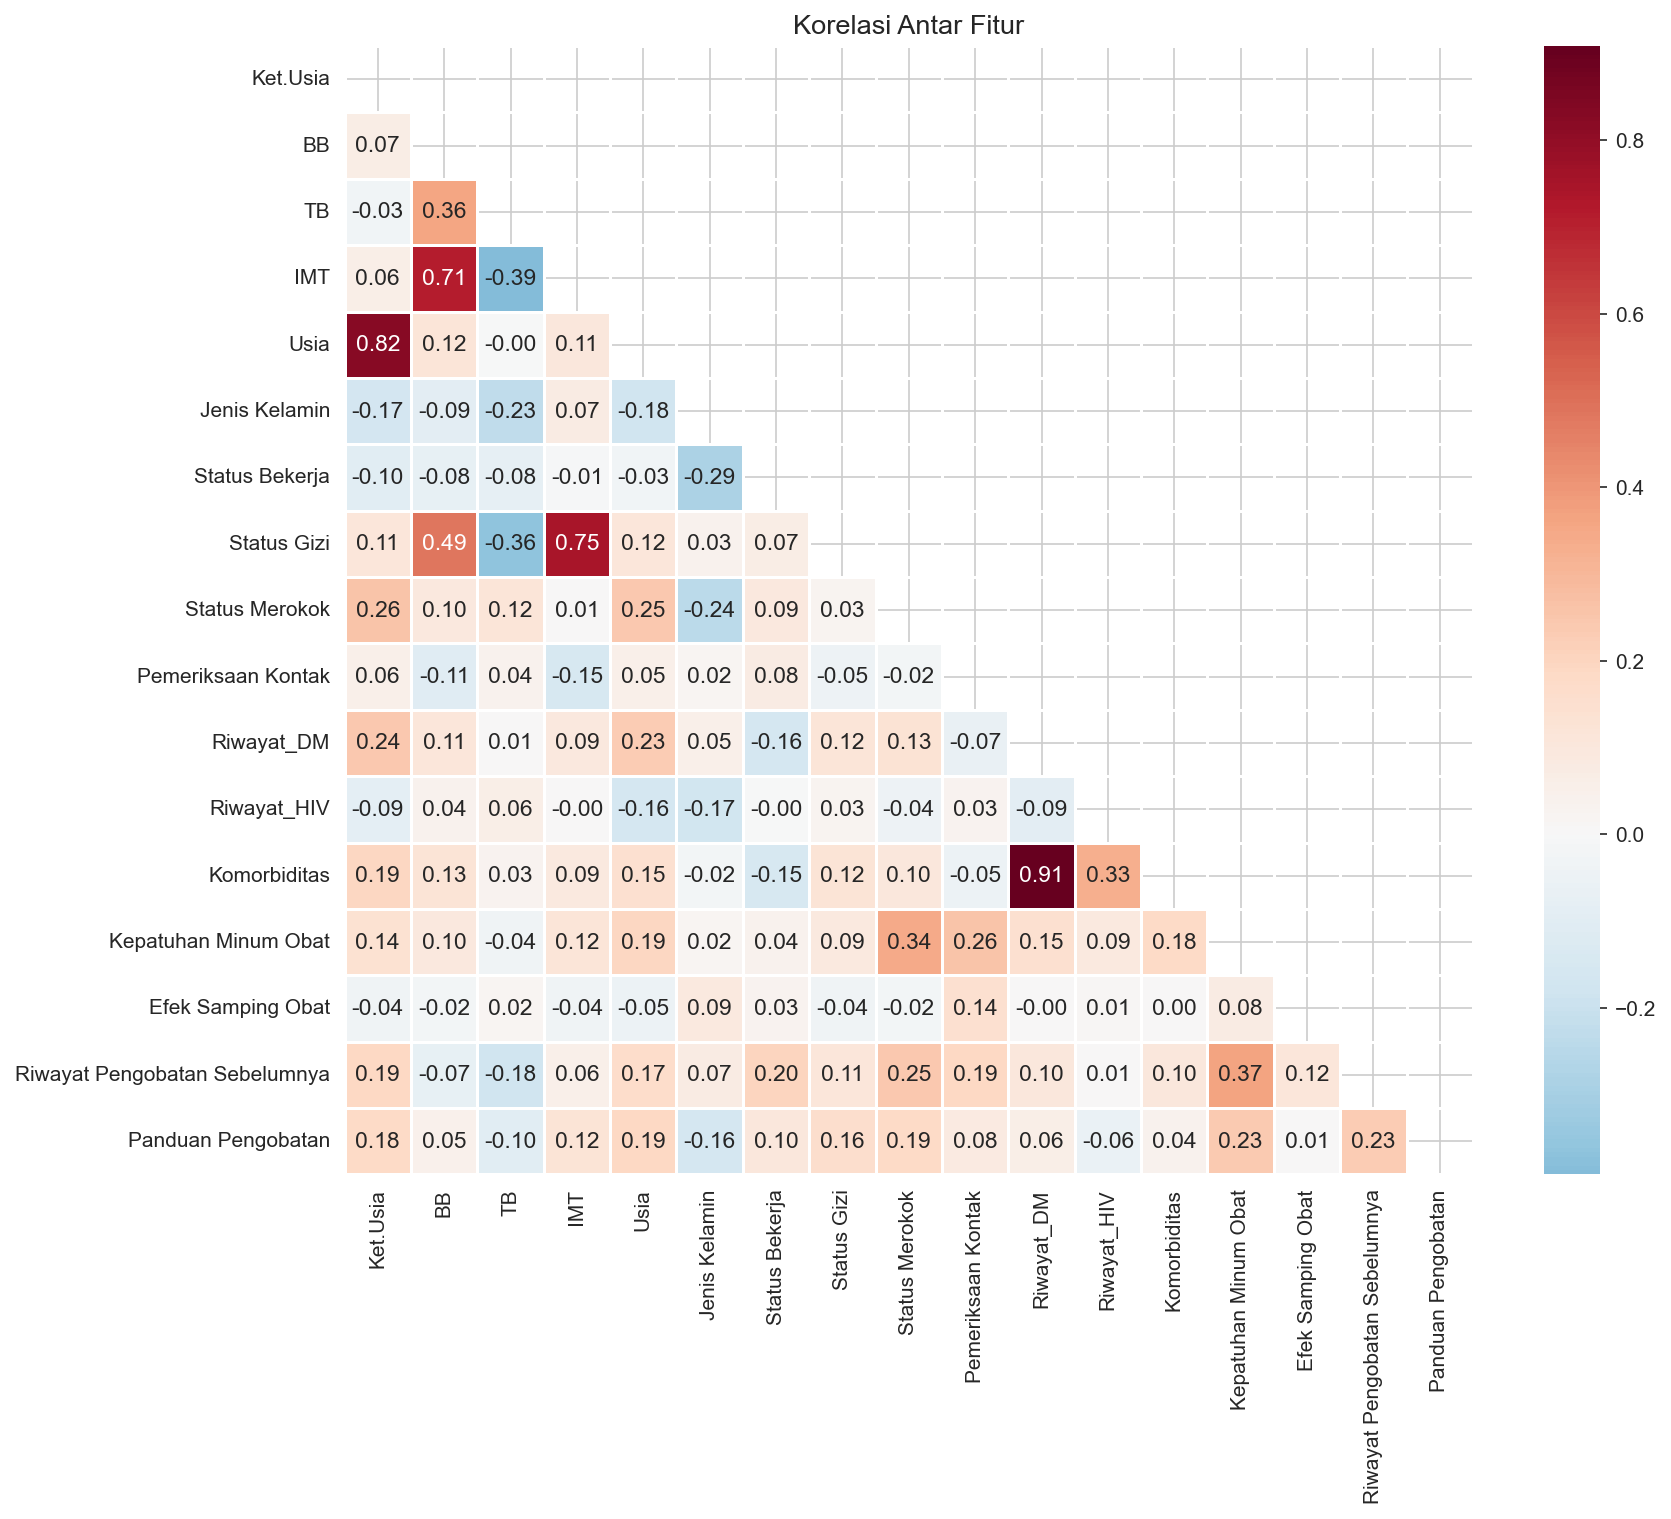

In [5]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png')
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.pdf')
plt.show()

## 3. Class Imbalance Analysis

Class counts: {'0': 105, '1': 46}
Percentages: {'0': 69.54, '1': 30.46}
Imbalance ratio: 2.28:1


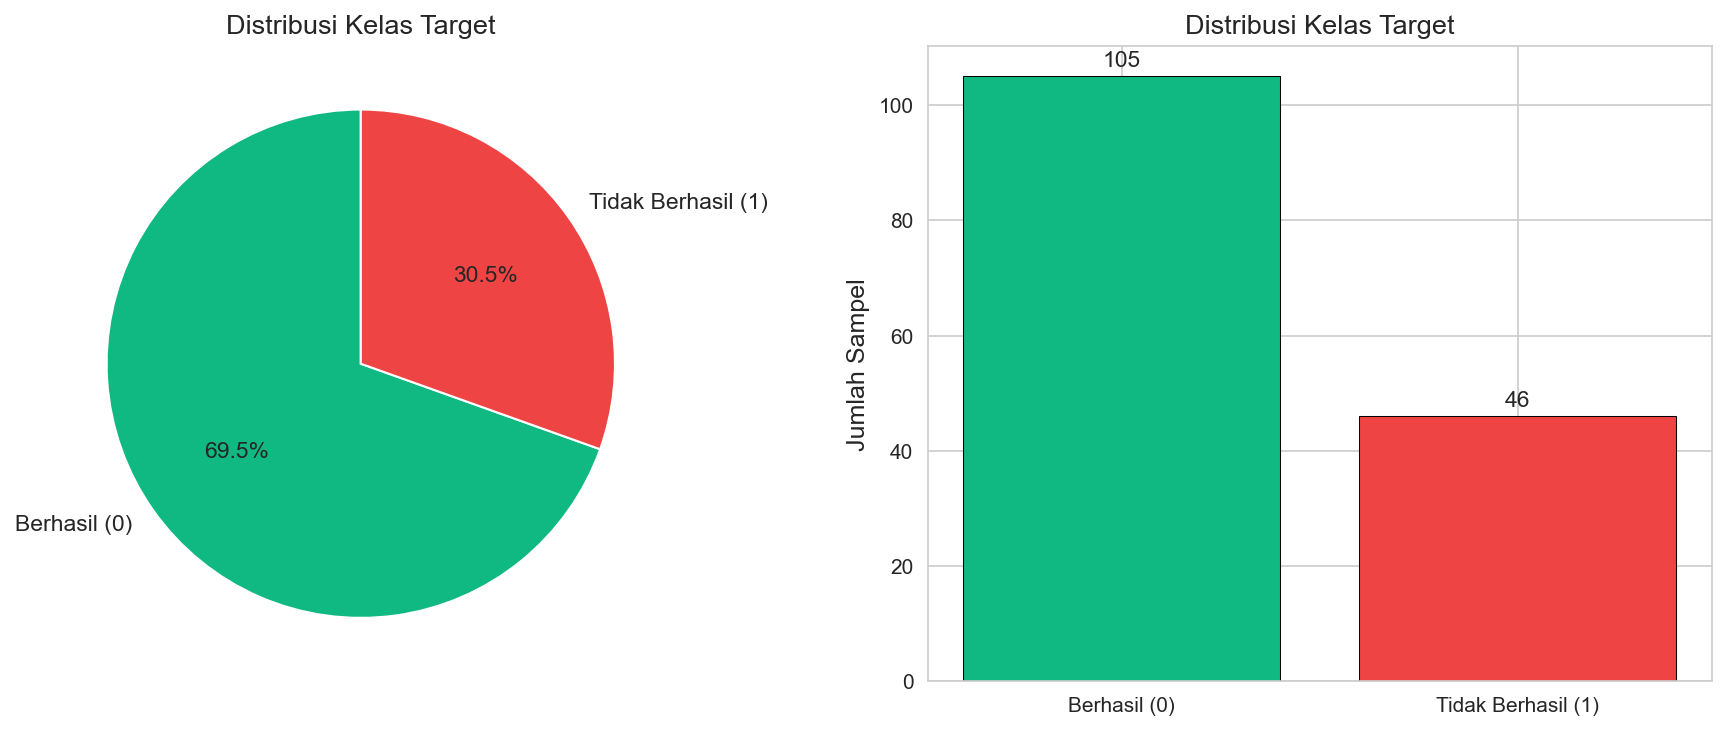

In [6]:
# Class distribution
class_dist = get_class_distribution(y)
print(f"Class counts: {class_dist['counts']}")
print(f"Percentages: {class_dist['percentages']}")
print(f"Imbalance ratio: {class_dist['imbalance_ratio']}:1")

label_map = {0: 'Berhasil (0)', 1: 'Tidak Berhasil (1)'}
counts = y.value_counts()
labels = [label_map.get(k, str(k)) for k in counts.index]
colors = ['#10b981', '#ef4444']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Distribusi Kelas Target')

# Bar chart
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi Kelas Target')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png')
plt.savefig(FIGURES_DIR / 'class_distribution.pdf')
plt.show()

## 4. Model Training & Evaluation

In [7]:
# Train all models (dengan SMOTE, sesuai konfigurasi web)
trainer = ModelTrainer(n_folds=5)
evaluator = ModelEvaluator()

training_results = trainer.train(X, y, use_smote=True)
split_info = training_results.get('split_info', {})
smote_info = training_results.get('smote_info', {})

X_train = training_results['X_train']
X_test = training_results['X_test']
y_train = training_results['y_train']
y_test = training_results['y_test']

print("\nSplit data utama tetap 70/15/15 sebelum SMOTE:")
print(f"  Total data bersih: {split_info.get('total_cleaned', len(y))}")
print(f"  Training asli: {split_info.get('train_size', 'N/A')}")
print(f"  Validation: {split_info.get('validation_size', 'N/A')}")
print(f"  Testing: {split_info.get('test_size', len(X_test))}")
print(f"Training setelah SMOTE: {smote_info.get('train_size_after', len(X_train))}")
print("Catatan: SMOTE hanya diterapkan pada training set; validation dan testing tetap data asli.")
print(f"Best model: {training_results['best_model_name']}")
print(f"SMOTE applied: {training_results['smote_applied']}")

# Tampilkan CV F1-Score (sama seperti yang ditampilkan di web)
print(f"\n{'='*60}")
print("Perbandingan Skor F1 Cross Validation:")
print(f"(Angka ini yang ditampilkan di web)")
print(f"{'='*60}")
for name, cv in trainer.cv_results.items():
    f1_mean = cv['f1']['mean'] * 100
    f1_std = cv['f1']['std'] * 100
    print(f"  {name:30s} F1: {f1_mean:.2f}% (+/-{f1_std:.2f}%)")



=== Class Distribution ===
Original dataset: {0: 105, 1: 46} (total: 151)
Training set: {0: 73, 1: 32} (total: 105)
Training set size: 105
Validation set size: 23
Test set size: 23

=== SMOTE Applied ===
Training set after SMOTE: {0: 73, 1: 73} (total: 146)

=== Hybrid Feature Selection ===
Selected features (9): ['Ket.Usia', 'Status Bekerja', 'Status Merokok', 'Riwayat_DM', 'Riwayat_HIV', 'Kepatuhan Minum Obat', 'Efek Samping Obat', 'Riwayat Pengobatan Sebelumnya', 'Panduan Pengobatan']

=== Hyperparameter Tuning ===

Tuning Logistic Regression...
  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1: 0.9087

Tuning Decision Tree...
  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1: 0.8770

Tuning Support Vector Machine...
  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1: 0.9172

=== Cross Validation ===

Cross-validating Logistic Regression...
  Accuracy: 0.9106 (+/- 0.0519

In [8]:
# Evaluate all models
eval_results = evaluator.evaluate_all_models(trainer.models, X_test, y_test)

# Comparison table
comparison = evaluator.evaluate_train_test(
    trainer.models, X_train, y_train, X_test, y_test
)

# Display metrics table
metrics_data = []
for name, res in eval_results.items():
    m = res['metrics']
    metrics_data.append({
        'Model': name,
        'Accuracy': f"{m['accuracy']*100:.2f}%",
        'Precision': f"{m['precision']*100:.2f}%",
        'Recall': f"{m['recall']*100:.2f}%",
        'F1-Score': f"{m['f1_score']*100:.2f}%",
        'Specificity': f"{m.get('specificity', 0)*100:.2f}%",
        'AUC-ROC': f"{m.get('auc_roc', 0)*100:.2f}%",
    })
pd.DataFrame(metrics_data)


=== Logistic Regression ===
Accuracy:  0.8696
Precision: 0.7500
Recall:    0.8571
F1 Score:  0.8000
Confusion Matrix: TP=6, TN=14, FP=2, FN=1

=== Decision Tree ===
Accuracy:  0.6957
Precision: 0.5000
Recall:    0.5714
F1 Score:  0.5333
Confusion Matrix: TP=4, TN=12, FP=4, FN=3

=== Support Vector Machine ===
Accuracy:  0.8696
Precision: 0.7500
Recall:    0.8571
F1 Score:  0.8000
Confusion Matrix: TP=6, TN=14, FP=2, FN=1

=== Logistic Regression (Train/Test Comparison) ===
  Accuracy:    Tr=93.15% | Ts=86.96%
  Sensitivity: Tr=95.89% | Ts=85.71%
  Specificity: Tr=90.41% | Ts=87.50%
  AUC-ROC:     Tr=98.95% | Ts=91.96%

=== Decision Tree (Train/Test Comparison) ===
  Accuracy:    Tr=100.00% | Ts=69.57%
  Sensitivity: Tr=100.00% | Ts=57.14%
  Specificity: Tr=100.00% | Ts=75.00%
  AUC-ROC:     Tr=100.00% | Ts=66.07%

=== Support Vector Machine (Train/Test Comparison) ===
  Accuracy:    Tr=94.52% | Ts=86.96%
  Sensitivity: Tr=94.52% | Ts=85.71%
  Specificity: Tr=94.52% | Ts=87.50%
  AUC-R

,Model,Accuracy,Precision,Recall,F1-Score,Specificity,AUC-ROC
0,Logistic Regression,86.96%,75.00%,85.71%,80.00%,87.50%,91.96%
1,Decision Tree,69.57%,50.00%,57.14%,53.33%,75.00%,66.07%
2,Support Vector Machine,86.96%,75.00%,85.71%,80.00%,87.50%,87.50%


## 4b. Hybrid Feature Selection (Filter-Wrapper)

Metodologi sistematis-hibrida untuk seleksi fitur (defensibel untuk disertasi):
1. **Pra-seleksi** — buang fitur konstan, korelasi tinggi (|r|>0.8), VIF tinggi (>10).
2. **Kelompok A (statistik)** — Firth penalized logistic p<0.05 (robust di small n / quasi-separation).
3. **Kelompok B (klinis)** — variabel justifikasi klinis meski marginal (Riwayat_DM, Komorbiditas).
4. **Kelompok C (komputasional)** — RFE + Random Forest importance + stabilitas seleksi.
5. **Stabilitas** — RFE per fold (10-fold), Jaccard pairwise.

Subset final dibekukan ke `trainer.selected_features` dan dipersist ke `preprocessor.pkl`. Leakage-safe: seleksi hanya pada `X_train` post-SMOTE, `X_test`/`X_val` difilter pakai subset yang sama. Setelah `train()`, `X_test.columns` sudah berisi subset terpilih.

HYBRID FEATURE SELECTION SUMMARY
Total fitur kandidat : 17
Diterima (masuk ML)  : 9
Ditolak              : 8
Firth method         : firth
Stabilitas (Jaccard) : 0.797 (threshold 0.6, 10-fold)

Selected features (frozen subset):
  - Ket.Usia
  - Status Bekerja
  - Status Merokok
  - Riwayat_DM
  - Riwayat_HIV
  - Kepatuhan Minum Obat
  - Efek Samping Obat
  - Riwayat Pengobatan Sebelumnya
  - Panduan Pengobatan

Feature Selection Summary (Accepted/Rejected + alasan):


,Fitur,Status,Grup,OR (Firth),p-value,RF Imp.,RFE Rank,Sel. Rate,Alasan
0,Ket.Usia,accepted,C,0.958682,0.144889,0.228372,7.0,0.0,Diterima karena evidence komputasional (RF imp...
1,BB,rejected,pre,NaN,NaN,NaN,NaN,NaN,Dibuang karena multikolinearitas tinggi (VIF=2...
2,TB,rejected,pre,NaN,NaN,NaN,NaN,NaN,Dibuang karena multikolinearitas tinggi (VIF=1...
3,IMT,rejected,pre,NaN,NaN,NaN,NaN,NaN,Dibuang karena multikolinearitas tinggi (VIF=1...
4,Usia,rejected,pre,NaN,NaN,NaN,NaN,NaN,Dibuang karena redundansi tinggi (r=0.84) deng...
5,Jenis Kelamin,rejected,C,0.316510,0.226058,0.034012,5.0,0.0,"Ditolak: tidak signifikan (p=0.2261), tidak te..."
6,Status Bekerja,accepted,A,0.036691,0.014123,0.032664,1.0,0.8,Diterima karena signifikansi statistik (p=0.01...
7,Status Gizi,rejected,C,0.565474,0.491327,0.032739,6.0,0.0,"Ditolak: tidak signifikan (p=0.4913), tidak te..."
8,Status Merokok,accepted,A,100.525836,0.000577,0.106920,1.0,1.0,Diterima karena signifikansi statistik (p=0.00...
9,Pemeriksaan Kontak,rejected,C,1.940090,0.385057,0.038533,4.0,0.0,"Ditolak: tidak signifikan (p=0.3851), tidak te..."


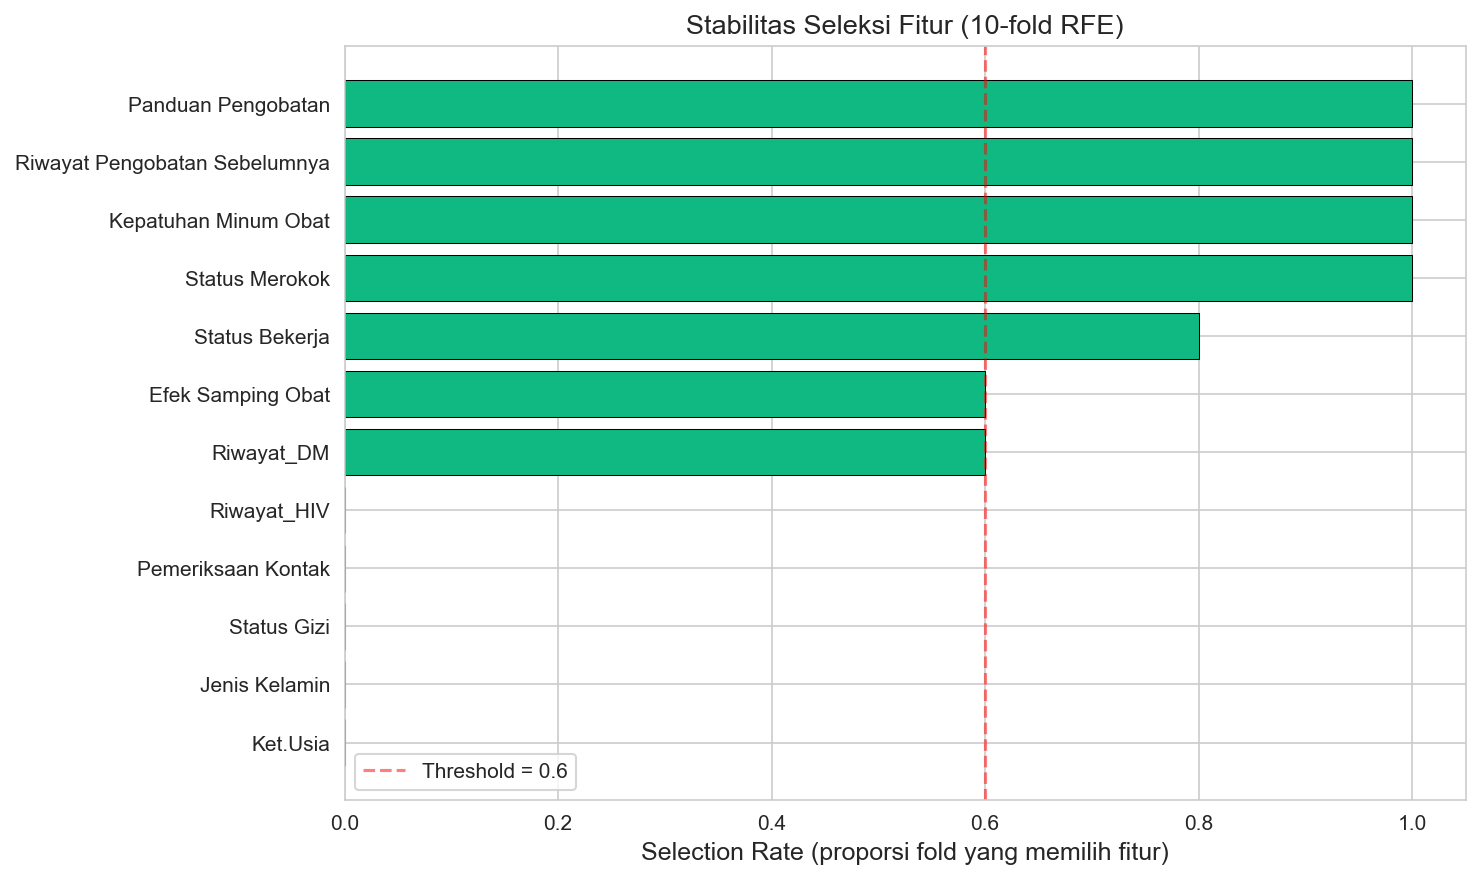

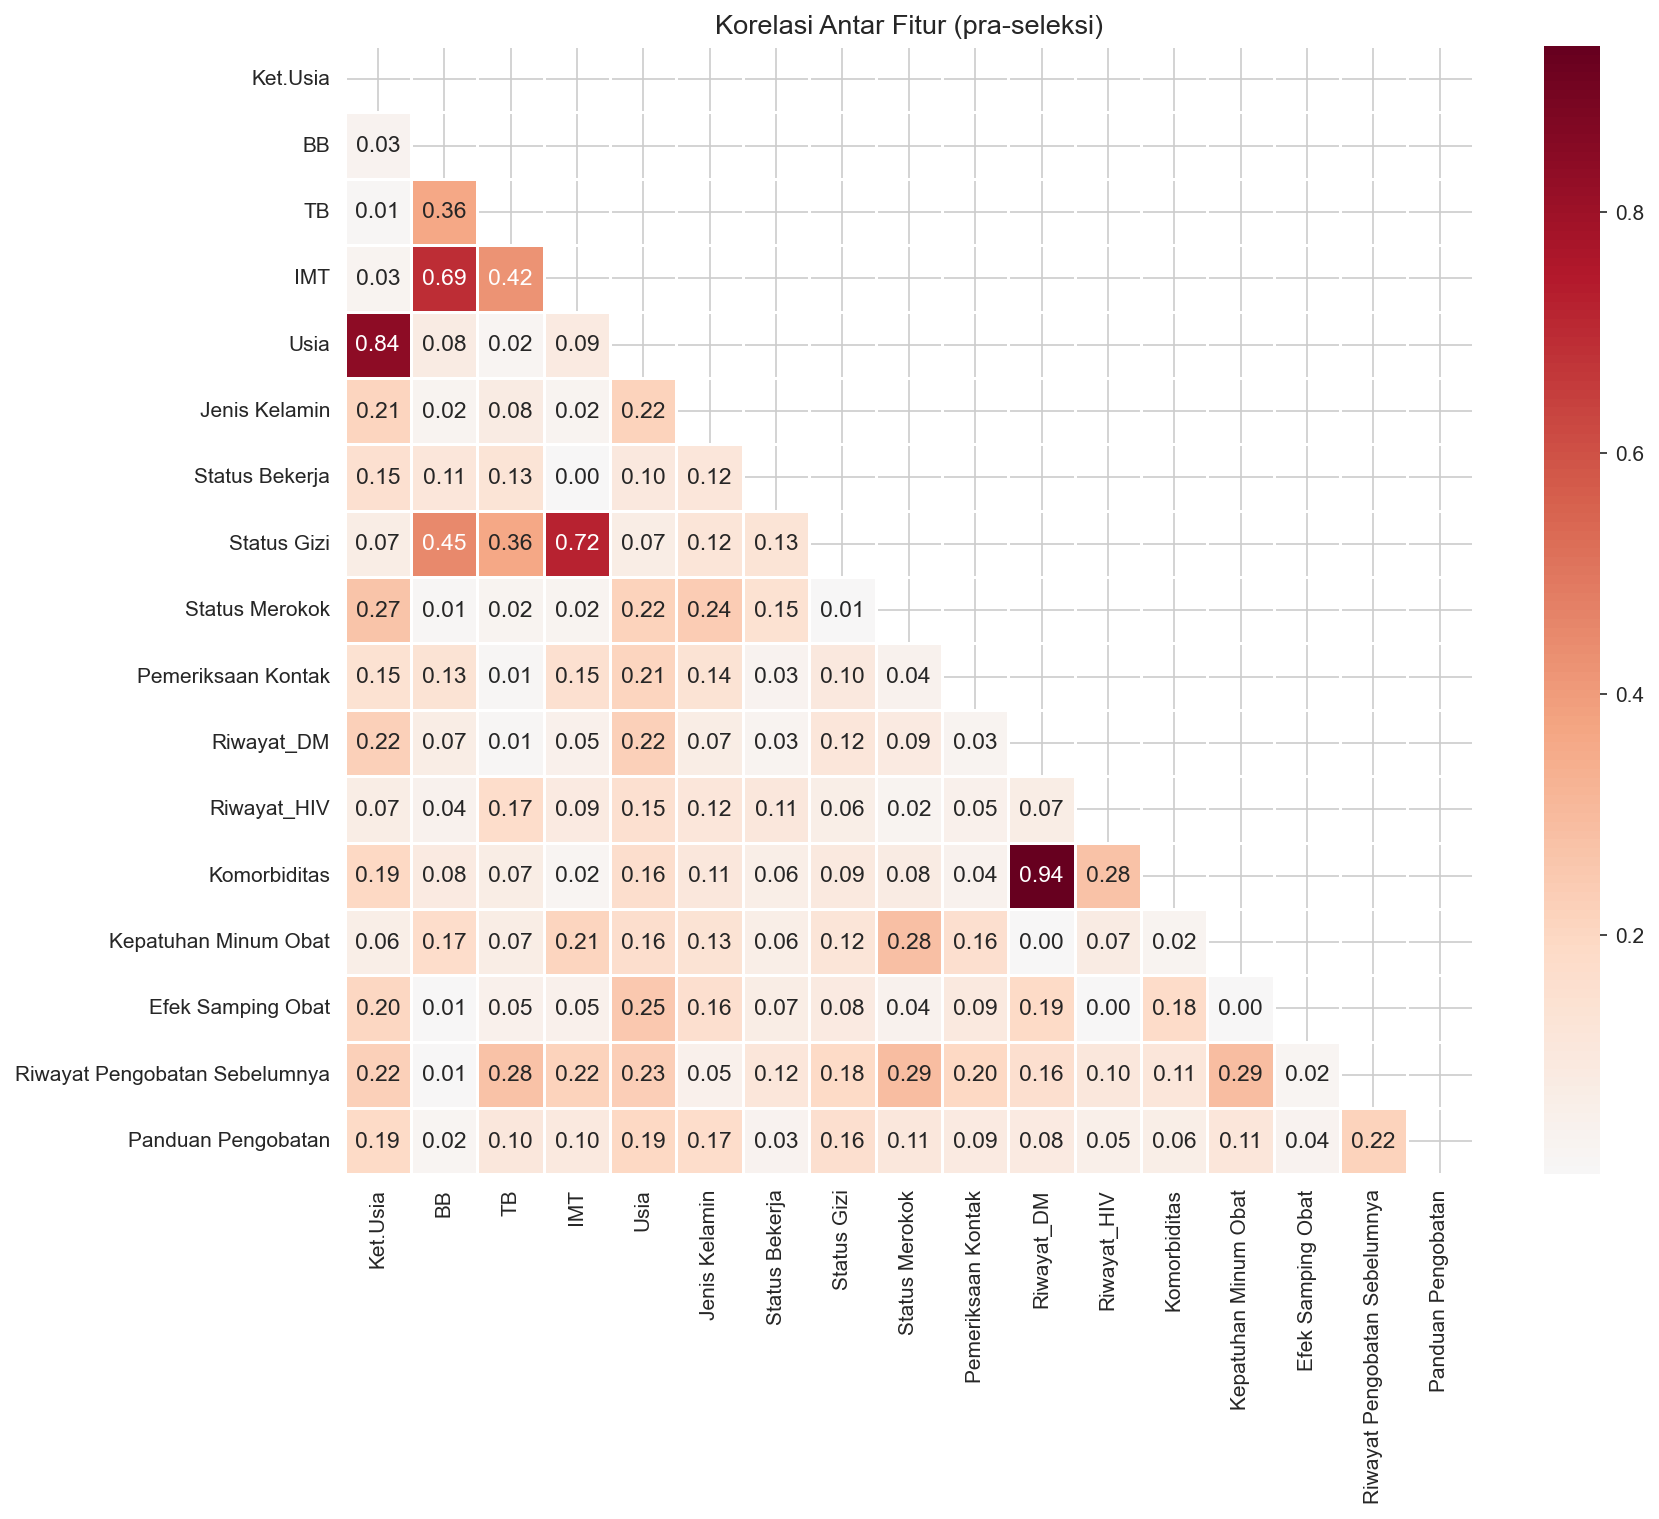

In [9]:
# Hybrid Feature Selection — hasil sudah dihitung di dalam trainer.train()
# (leakage-safe: seleksi pada X_train post-SMOTE saja).
fs_result = trainer.feature_selection_result
fs_features = trainer.selected_features

print("=" * 70)
print("HYBRID FEATURE SELECTION SUMMARY")
print("=" * 70)
print(f"Total fitur kandidat : {fs_result['summary']['total']}")
print(f"Diterima (masuk ML)  : {fs_result['summary']['accepted']}")
print(f"Ditolak              : {fs_result['summary']['rejected']}")
print(f"Firth method         : {fs_result['firth_method']}")
print(f"Stabilitas (Jaccard) : {fs_result['stability']['jaccard_mean']:.3f} "
      f"(threshold {fs_result['stability']['select_threshold']}, "
      f"{fs_result['stability']['n_folds']}-fold)")
print()
print("Selected features (frozen subset):")
for f in fs_features:
    print(f"  - {f}")

# Tabel verdict per-fitur (Diterima/Ditolak + alasan)
fs_df = pd.DataFrame(fs_result['features'])
fs_display = fs_df[['name', 'status', 'group', 'odds_ratio', 'p_value',
                    'rf_importance', 'rfe_rank', 'selection_rate', 'reason']].copy()
fs_display.columns = ['Fitur', 'Status', 'Grup', 'OR (Firth)', 'p-value',
                      'RF Imp.', 'RFE Rank', 'Sel. Rate', 'Alasan']
print("\nFeature Selection Summary (Accepted/Rejected + alasan):")
display(fs_display)

# Visualisasi: bar selection_rate per fitur (stabilitas)
fig, ax = plt.subplots(figsize=(10, 6))
sr = fs_result['stability']['selection_rate']
sr_series = pd.Series(sr).sort_values()
colors = ['#10b981' if v >= fs_result['stability']['select_threshold'] else '#94a3b8'
          for v in sr_series.values]
ax.barh(sr_series.index, sr_series.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=fs_result['stability']['select_threshold'], color='red', linestyle='--',
           alpha=0.5, label=f"Threshold = {fs_result['stability']['select_threshold']}")
ax.set_xlabel('Selection Rate (proporsi fold yang memilih fitur)')
ax.set_title('Stabilitas Seleksi Fitur (10-fold RFE)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_selection_stability.png')
plt.savefig(FIGURES_DIR / 'feature_selection_stability.pdf')
plt.show()

# Korelasi heatmap pada fitur yang survive pra-seleksi
corr_labels = fs_result['correlation_matrix']['labels']
corr_matrix = np.array(fs_result['correlation_matrix']['matrix'])
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            xticklabels=corr_labels, yticklabels=corr_labels)
ax.set_title('Korelasi Antar Fitur (pra-seleksi)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_selection_correlation.png')
plt.savefig(FIGURES_DIR / 'feature_selection_correlation.pdf')
plt.show()

## 5. Bootstrap 95% Confidence Intervals

In [10]:
# Bootstrap CI for all models
bootstrap_results = evaluator.get_all_bootstrap_ci(trainer.models, X_test, y_test, n_iter=1000)

ci_rows = []
for name, ci in bootstrap_results.items():
    row = {'Model': name}
    for metric, vals in ci.items():
        row[f'{metric}'] = f"{vals['mean']*100:.1f}% [{vals['ci_lower']*100:.1f}-{vals['ci_upper']*100:.1f}]"
    ci_rows.append(row)

ci_df = pd.DataFrame(ci_rows)
print("Bootstrap 95% Confidence Intervals (1000 iterations):")
ci_df

Bootstrap 95% Confidence Intervals (1000 iterations):


,Model,accuracy,precision,recall,f1_score,specificity,auc_roc
0,Logistic Regression,86.8% [73.9-100.0],74.6% [40.0-100.0],85.9% [50.0-100.0],78.7% [50.0-100.0],87.2% [68.8-100.0],91.9% [77.6-100.0]
1,Decision Tree,69.7% [52.1-87.0],50.2% [14.3-85.7],57.5% [16.7-100.0],51.9% [16.7-80.0],74.9% [50.0-94.1],66.2% [43.3-87.2]
2,Support Vector Machine,86.8% [73.9-100.0],74.6% [40.0-100.0],85.9% [50.0-100.0],78.7% [50.0-100.0],87.2% [68.8-100.0],87.2% [68.8-100.0]


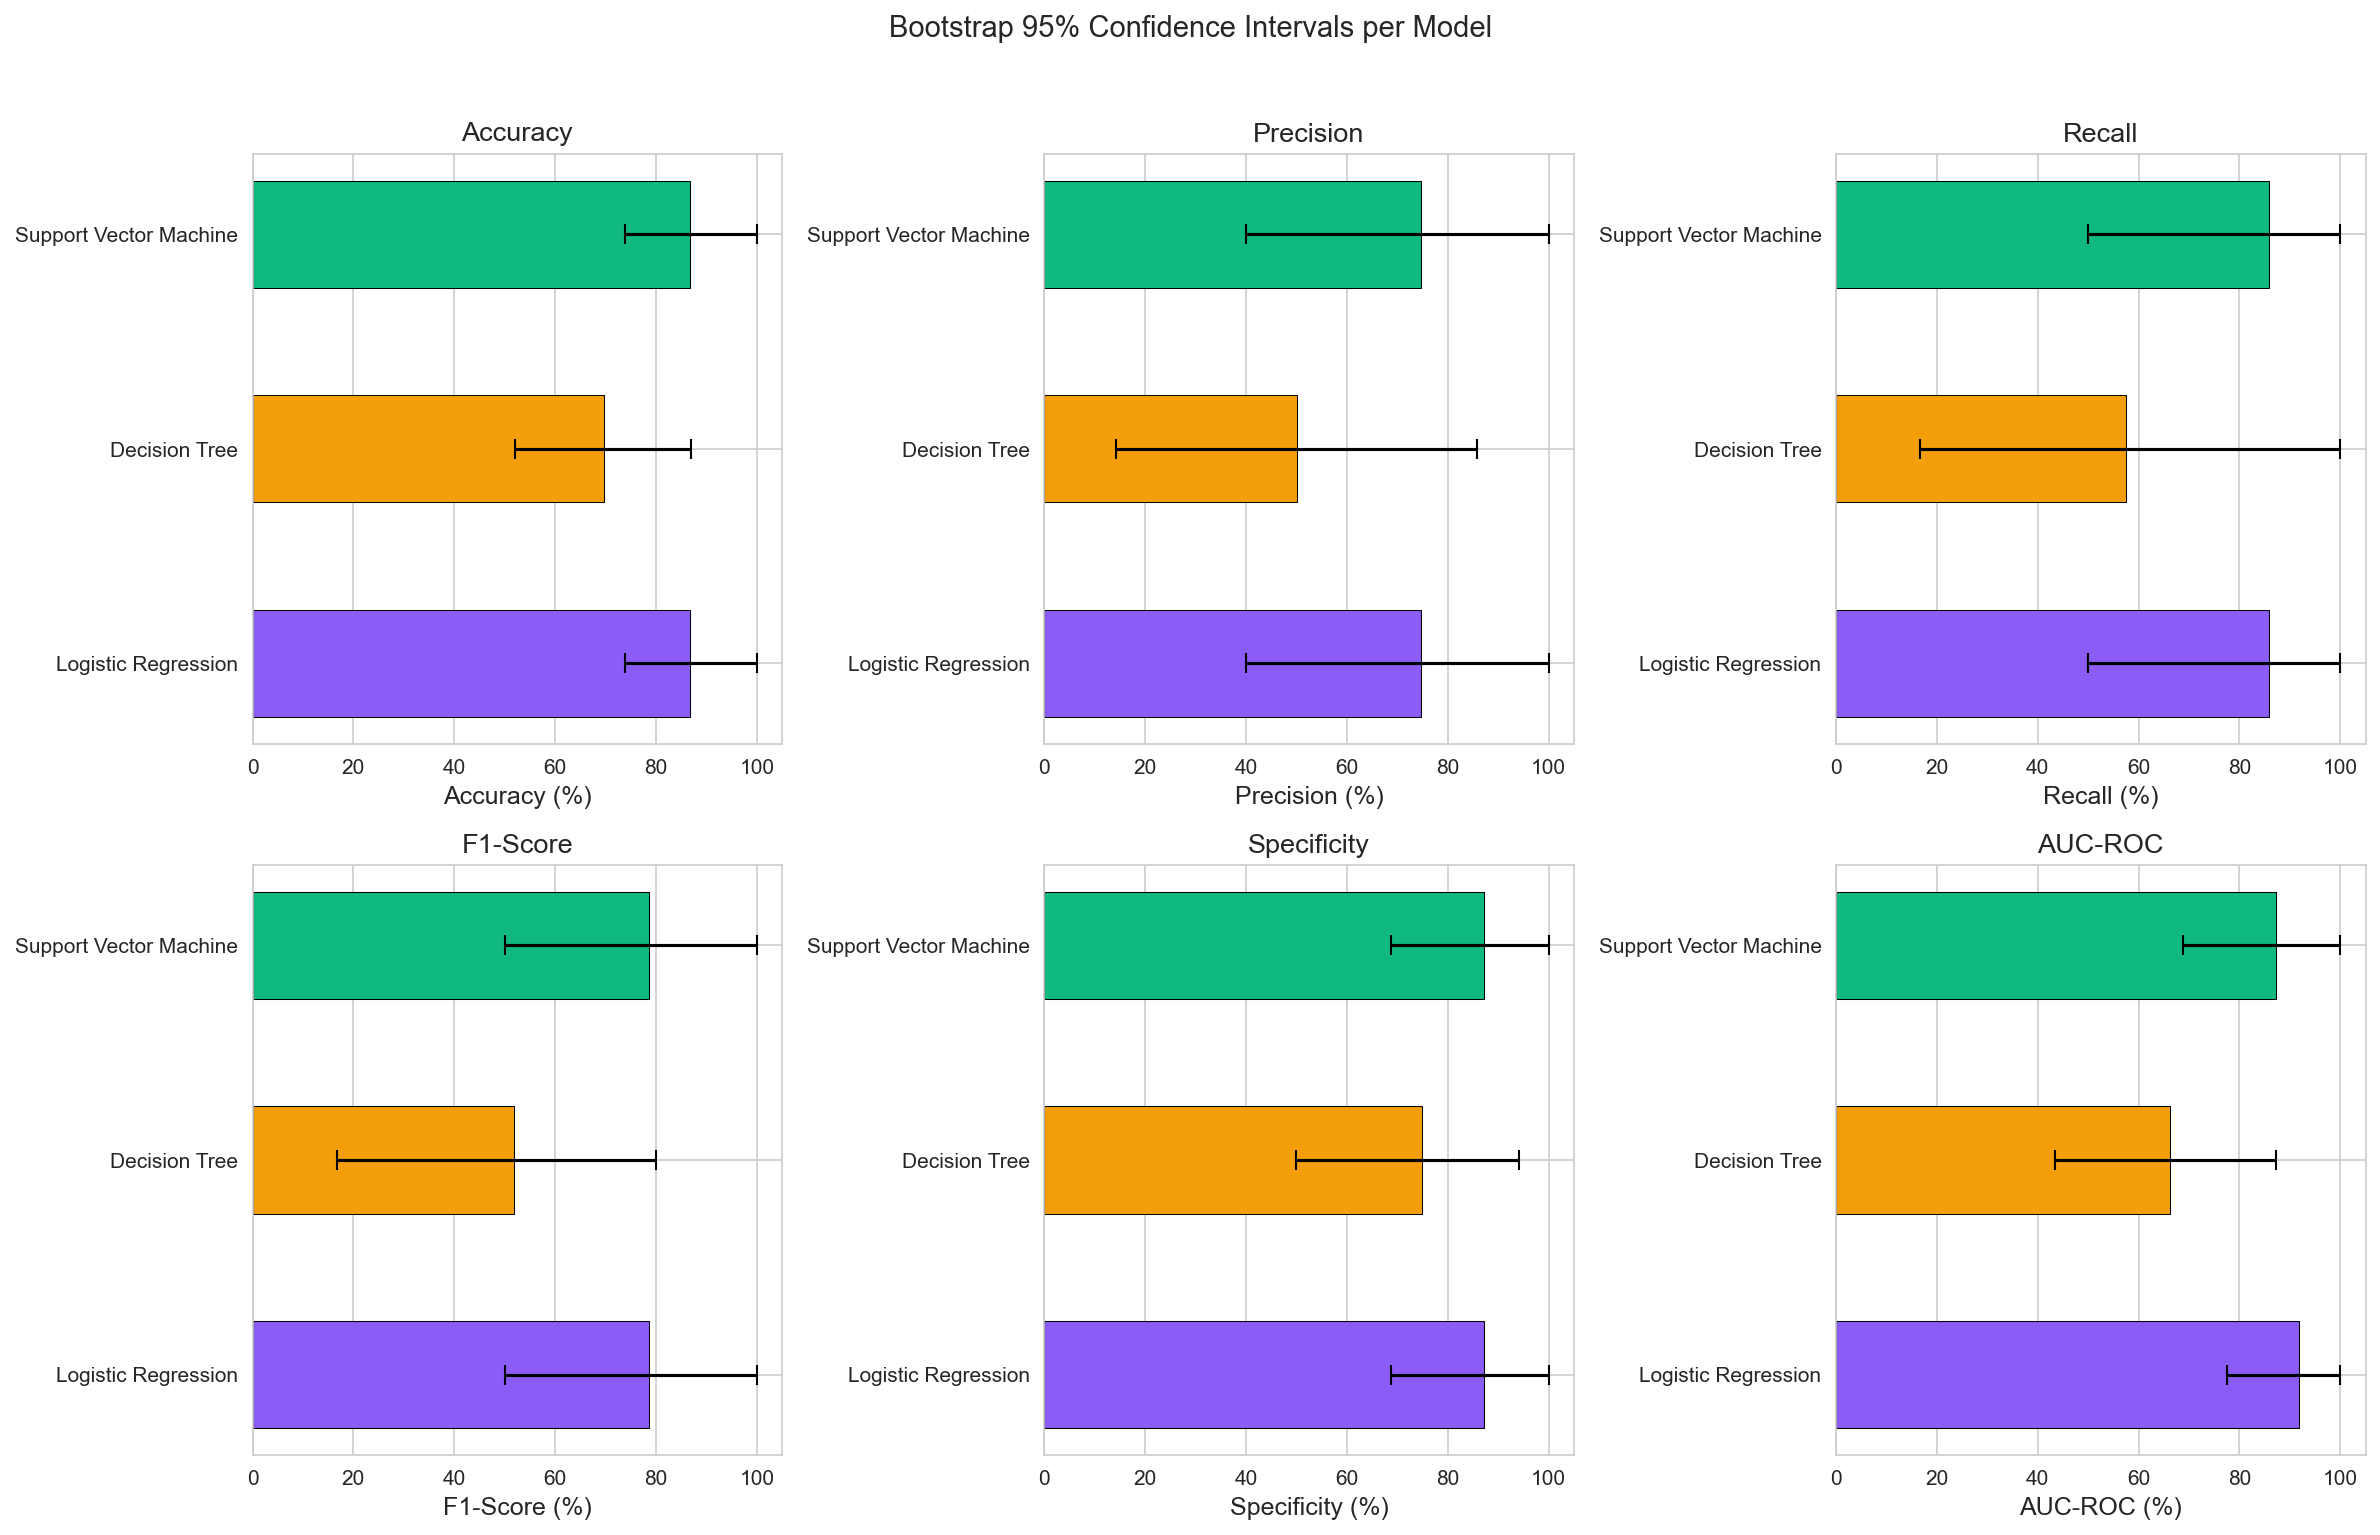

In [11]:
# Visualize bootstrap CI
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'specificity', 'auc_roc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC-ROC']
model_colors = {'Logistic Regression': '#8b5cf6', 'Decision Tree': '#f59e0b', 'Support Vector Machine': '#10b981'}

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx // 3][idx % 3]
    models = list(bootstrap_results.keys())
    means = [bootstrap_results[m][metric]['mean'] * 100 for m in models]
    ci_low = [bootstrap_results[m][metric]['ci_lower'] * 100 for m in models]
    ci_high = [bootstrap_results[m][metric]['ci_upper'] * 100 for m in models]
    errs = [[m - l for m, l in zip(means, ci_low)], [h - m for m, h in zip(means, ci_high)]]
    colors = [model_colors.get(m, '#6366f1') for m in models]

    bars = ax.barh(models, means, xerr=errs, color=colors, edgecolor='black',
                   linewidth=0.5, capsize=5, height=0.5)
    ax.set_xlabel(f'{label} (%)')
    ax.set_title(label)
    ax.set_xlim(0, 105)

plt.suptitle('Bootstrap 95% Confidence Intervals per Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bootstrap_ci.png')
plt.savefig(FIGURES_DIR / 'bootstrap_ci.pdf')
plt.show()

## 6. ROC & Precision-Recall Curves

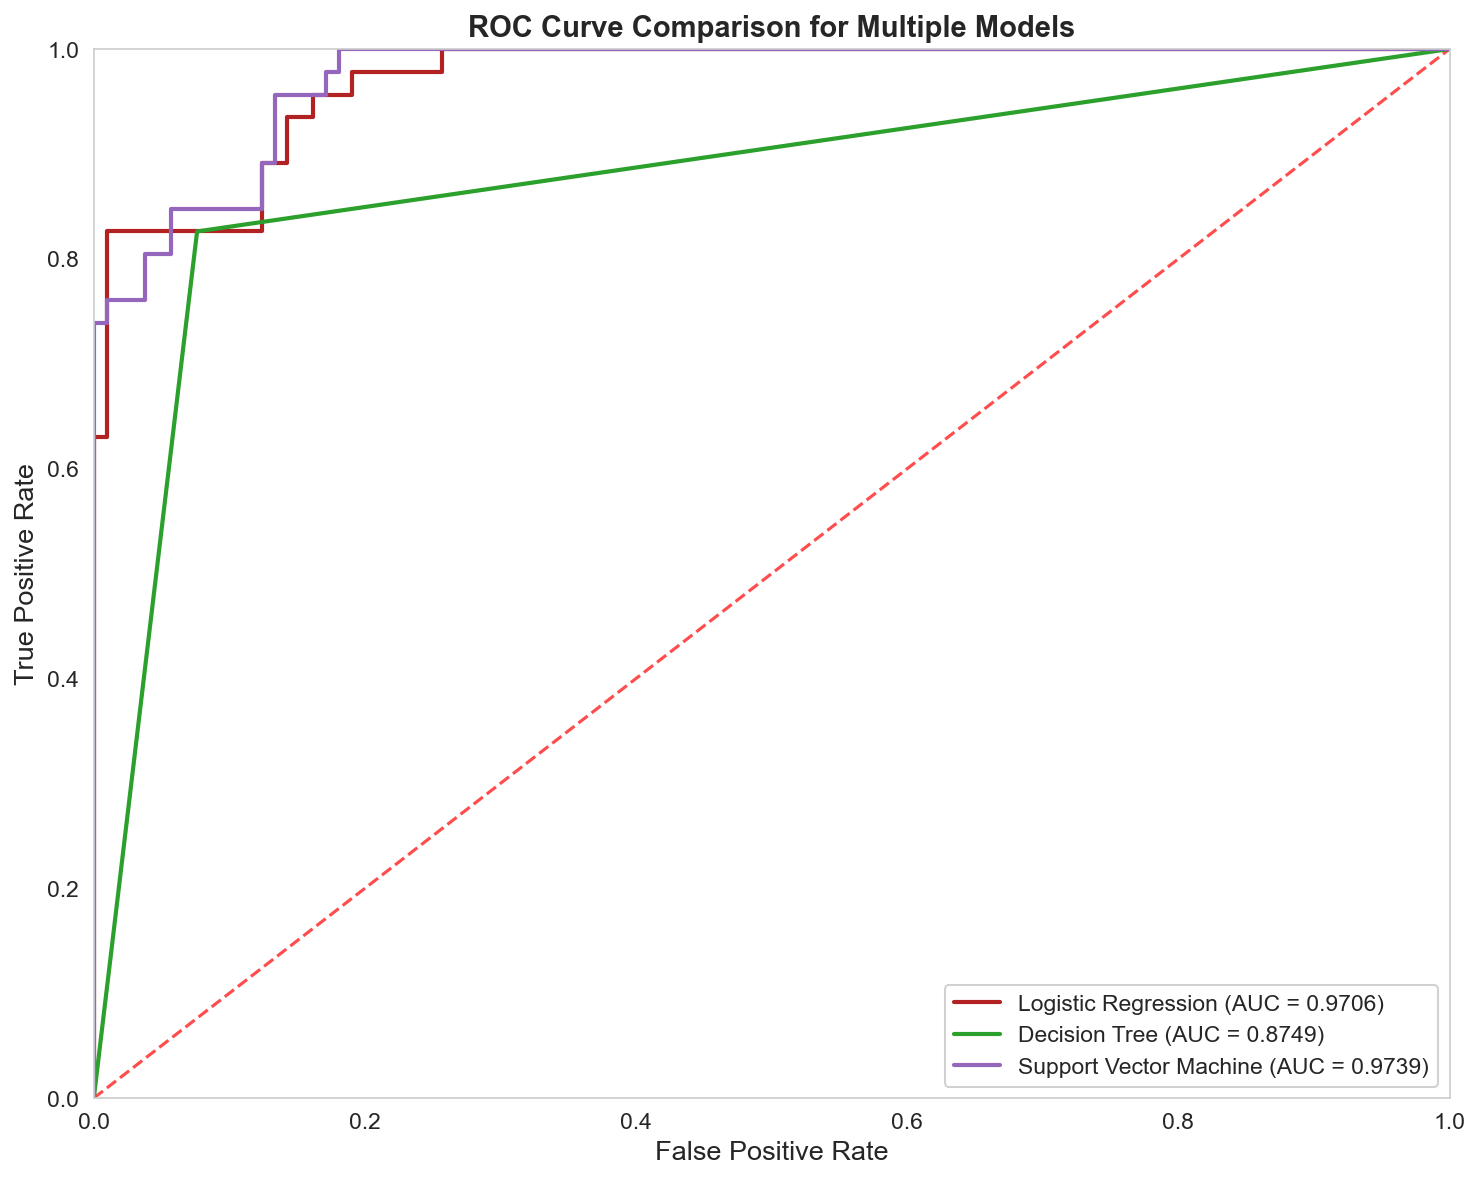

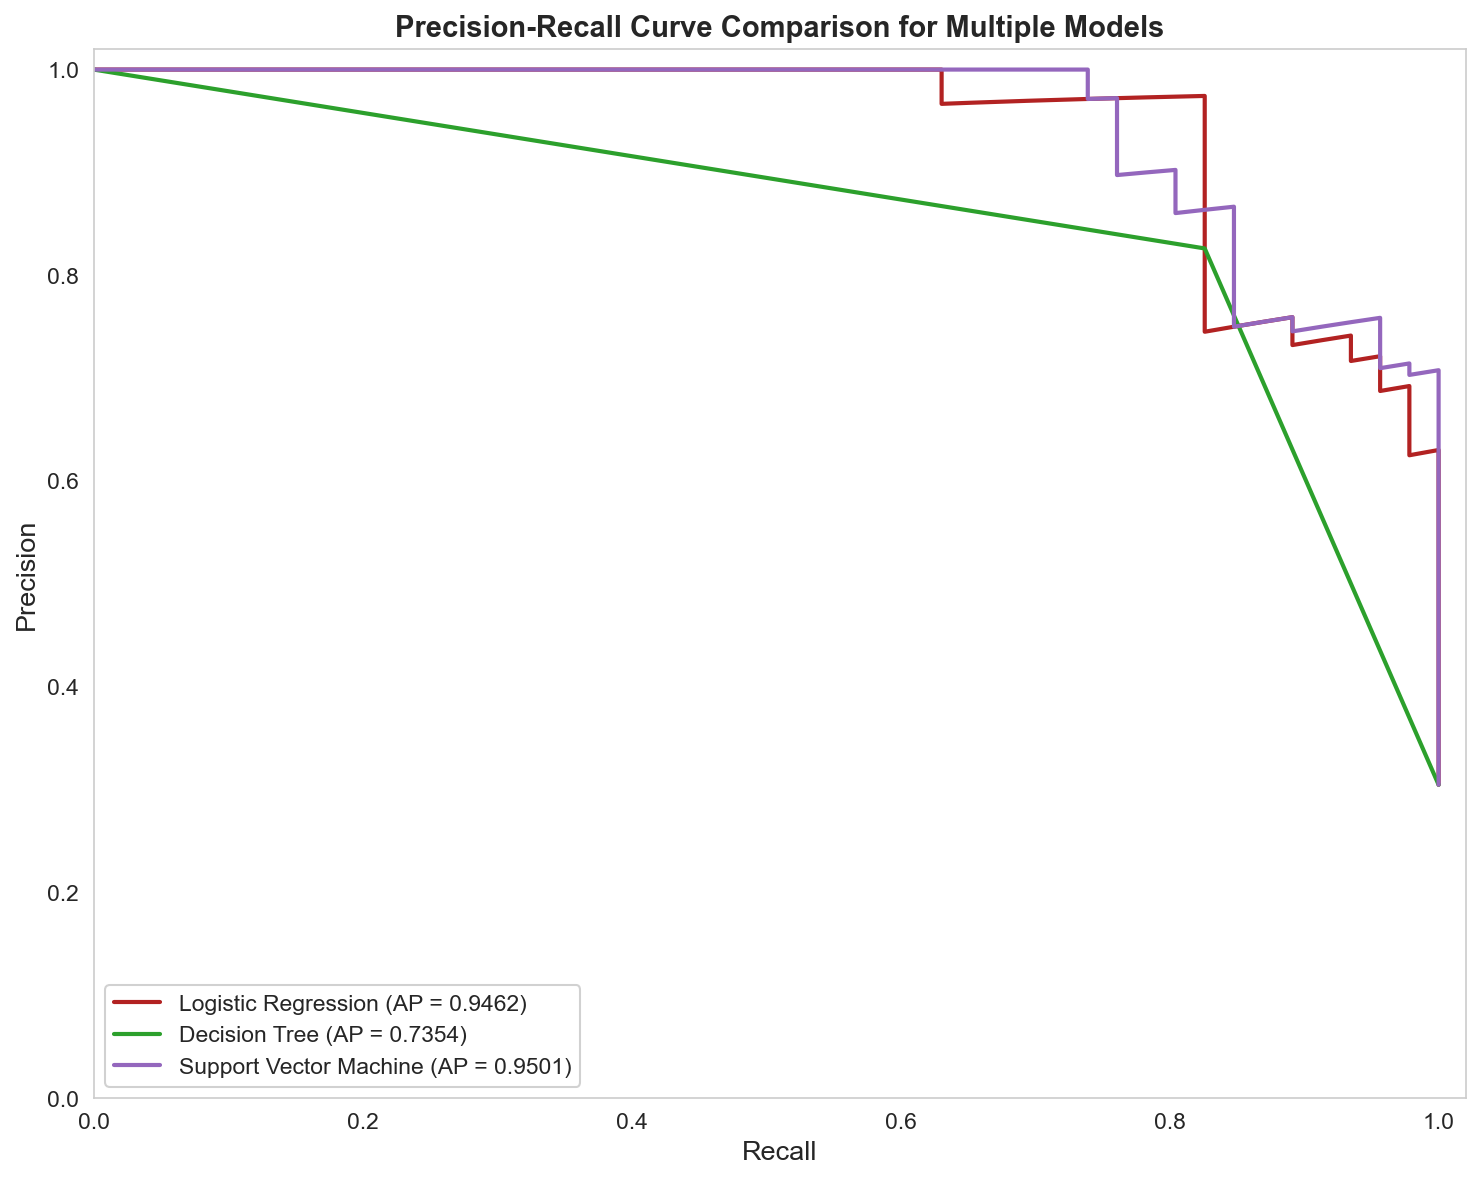

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

model_colors = {
    'Logistic Regression': '#b22222',
    'Decision Tree': '#2ca02c',
    'Support Vector Machine': '#9467bd'
}

# === ROC Curve Comparison (using CV predictions for smooth curves) ===
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5, alpha=0.7)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trainer.models.items():
    # Cross-val predict gives predictions for all samples (smoother ROC)
    y_proba_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba_cv)
    auc = roc_auc_score(y, y_proba_cv)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})',
            color=model_colors.get(name, None), linewidth=2)

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison for Multiple Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.tick_params(labelsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve_comparison.png')
plt.savefig(FIGURES_DIR / 'roc_curve_comparison.pdf')
plt.show()

# === Precision-Recall Curve Comparison (CV) ===
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in trainer.models.items():
    y_proba_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    prec, rec, _ = precision_recall_curve(y, y_proba_cv)
    ap = average_precision_score(y, y_proba_cv)
    ax.plot(rec, prec, label=f'{name} (AP = {ap:.4f})',
            color=model_colors.get(name, None), linewidth=2)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve Comparison for Multiple Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11, framealpha=0.9)
ax.set_xlim([0.0, 1.02])
ax.set_ylim([0.0, 1.02])
ax.tick_params(labelsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curve_comparison.png')
plt.savefig(FIGURES_DIR / 'pr_curve_comparison.pdf')
plt.show()

## 7. Confusion Matrix Heatmaps

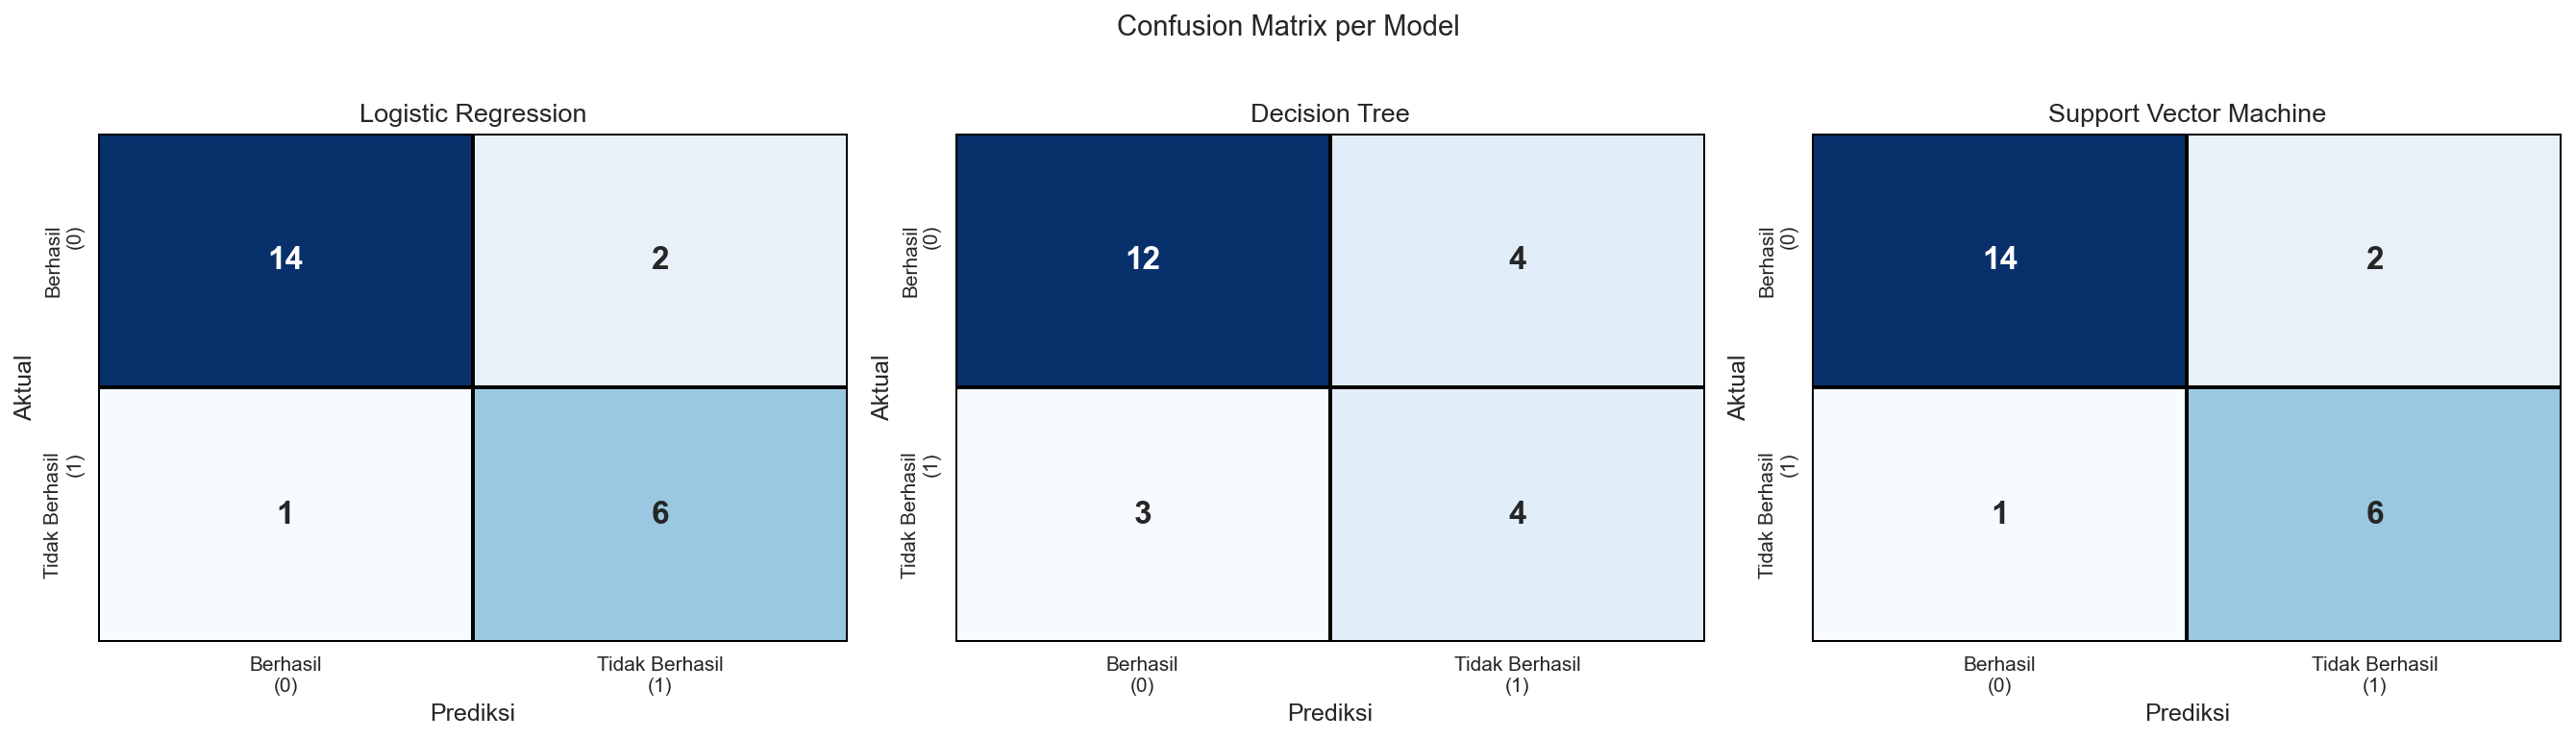

In [13]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

n_models = len(trainer.models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

labels_display = ['Berhasil\n(0)', 'Tidak Berhasil\n(1)']

for idx, (name, model) in enumerate(trainer.models.items()):
    ax = axes[idx]
    y_pred = model.predict(X_test)
    cm = sk_confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_display, yticklabels=labels_display,
                linewidths=1, linecolor='black', cbar=False,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrix per Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png')
plt.savefig(FIGURES_DIR / 'confusion_matrices.pdf')
plt.show()

## 8. Calibration Curves & Brier Scores

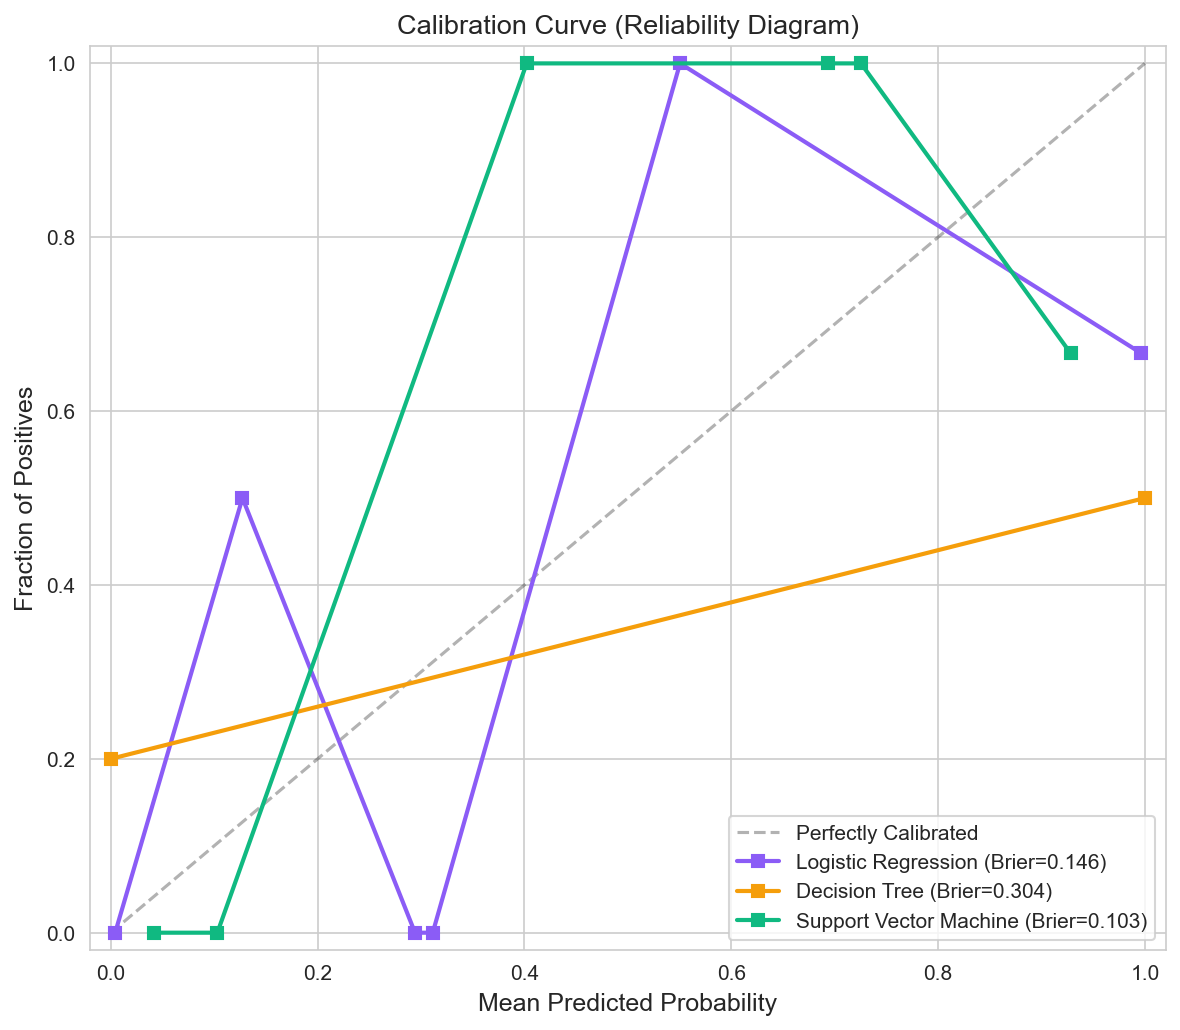


Brier Scores (lower is better):
  Logistic Regression: 0.1462
  Decision Tree: 0.3043
  Support Vector Machine: 0.1034


In [14]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model_colors_cal = {
    'Logistic Regression': '#8b5cf6',
    'Decision Tree': '#f59e0b',
    'Support Vector Machine': '#10b981'
}

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfectly Calibrated')

brier_scores = {}
for name, model in trainer.models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_test, y_proba)
    brier_scores[name] = brier
    ax.plot(prob_pred, prob_true, 's-', label=f'{name} (Brier={brier:.3f})',
            color=model_colors_cal.get(name, None), linewidth=2, markersize=6)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Reliability Diagram)')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'calibration_curves.png')
plt.savefig(FIGURES_DIR / 'calibration_curves.pdf')
plt.show()

print("\nBrier Scores (lower is better):")
for name, score in brier_scores.items():
    print(f"  {name}: {score:.4f}")

In [15]:
## 9. Feature Importance & Odds Ratio Forest Plot

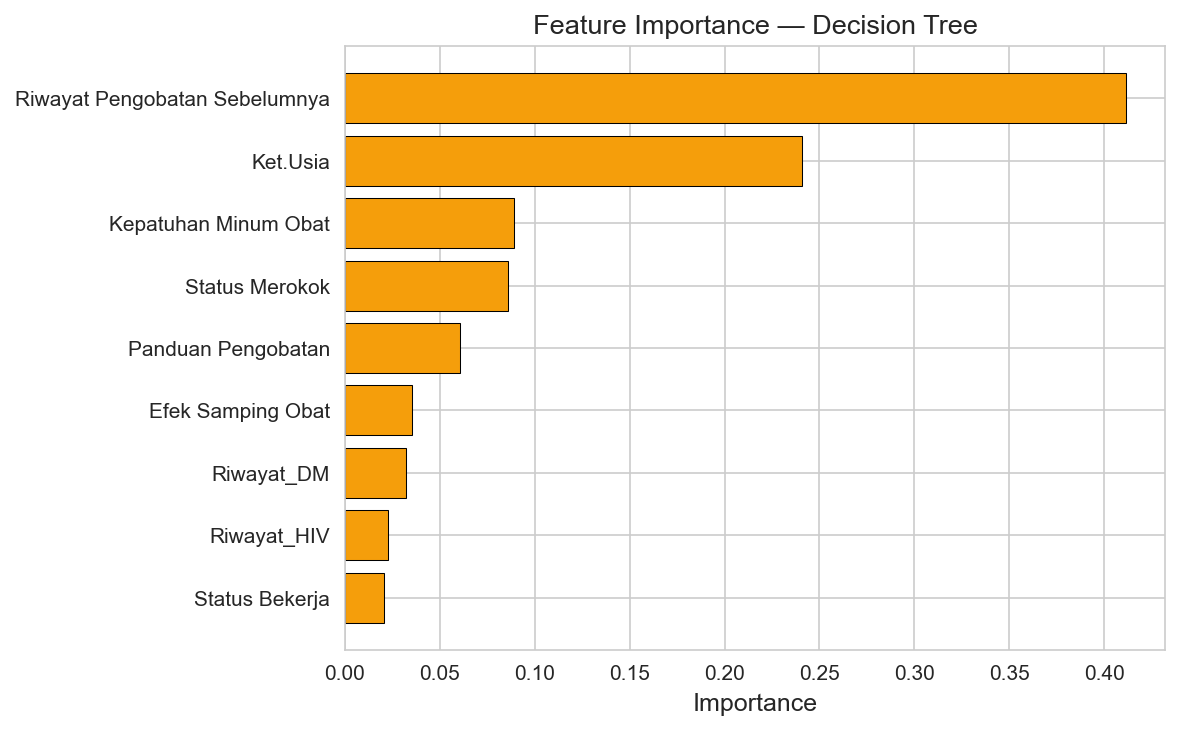

In [16]:
feature_names = list(X_test.columns)
# Lewatkan feature_selection_result agar LR odds ratio pakai Firth (single source of truth),
# bukan Wald approx lama. SHAP analitik untuk semua model.
interp = get_all_interpretability(
    trainer.models, X_test, y_test, feature_names,
    feature_selection_result=trainer.feature_selection_result,
)

# Decision Tree Feature Importance
dt_key = [k for k in interp if 'Decision Tree' in k]
if dt_key:
    fi = interp[dt_key[0]].get('feature_importance', [])
    if fi:
        fi_df = pd.DataFrame(fi).sort_values('importance', ascending=True)

        fig, ax = plt.subplots(figsize=(8, max(5, len(fi_df) * 0.4)))
        bars = ax.barh(fi_df['feature'], fi_df['importance'], color='#f59e0b',
                       edgecolor='black', linewidth=0.5)
        ax.set_xlabel('Importance')
        ax.set_title('Feature Importance — Decision Tree')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'feature_importance_dt.png')
        plt.savefig(FIGURES_DIR / 'feature_importance_dt.pdf')
        plt.show()

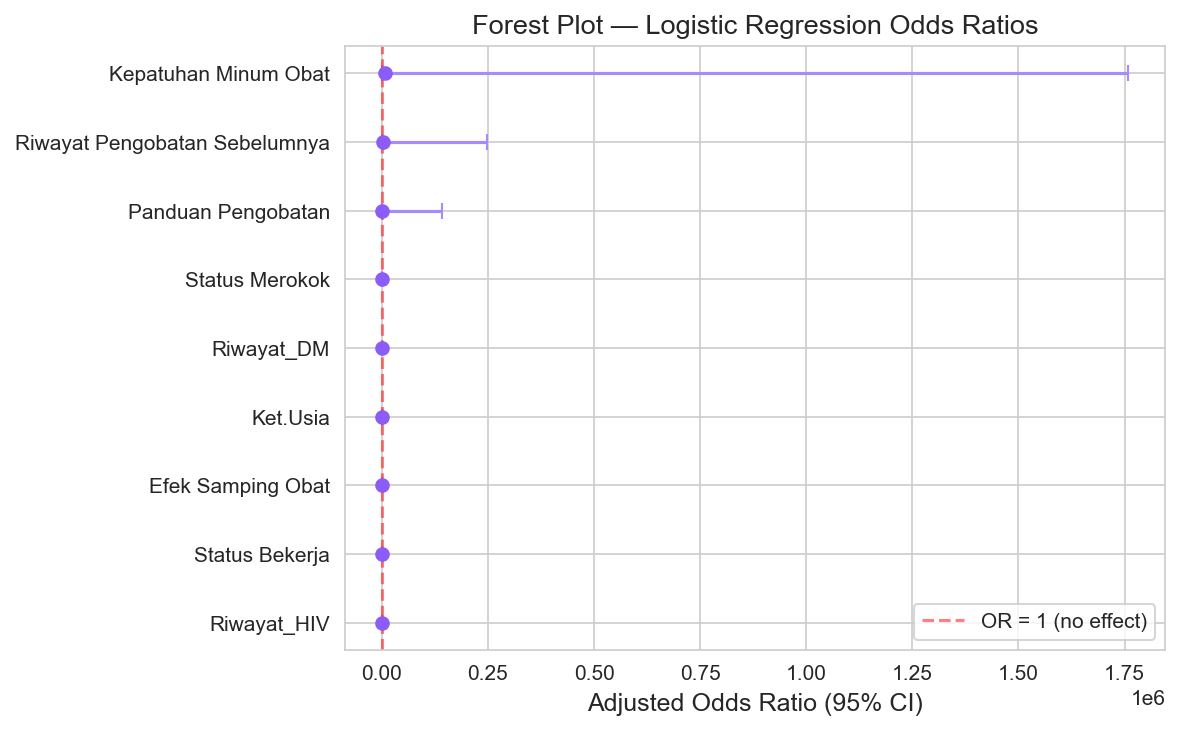


Odds Ratio Table:
                      feature  odds_ratio  ci_lower     ci_upper  p_value  significant
                  Riwayat_HIV    0.001427  0.000002 9.230267e-01 0.047227         True
               Status Bekerja    0.036691  0.002619 5.140183e-01 0.014123         True
            Efek Samping Obat    0.167447  0.026520 1.057265e+00 0.057332        False
                     Ket.Usia    0.958682  0.905808 1.014641e+00 0.144889        False
                   Riwayat_DM    6.937112  0.936310 5.139697e+01 0.058014        False
               Status Merokok  100.525836  7.281857 1.387756e+03 0.000577         True
           Panduan Pengobatan  526.904206  1.963045 1.414272e+05 0.028064         True
Riwayat Pengobatan Sebelumnya 3272.861964 43.053115 2.488002e+05 0.000250         True
         Kepatuhan Minum Obat 6336.160507 22.830769 1.758457e+06 0.002290         True


In [17]:
# Logistic Regression Odds Ratio Forest Plot
lr_key = [k for k in interp if 'Logistic Regression' in k]
if lr_key:
    ors = interp[lr_key[0]].get('odds_ratios', [])
    if ors:
        or_df = pd.DataFrame(ors).sort_values('odds_ratio', ascending=True)

        fig, ax = plt.subplots(figsize=(8, max(5, len(or_df) * 0.4)))
        y_pos = range(len(or_df))

        # Plot CI as horizontal error bars
        ax.errorbar(or_df['odds_ratio'], y_pos,
                     xerr=[or_df['odds_ratio'] - or_df['ci_lower'],
                           or_df['ci_upper'] - or_df['odds_ratio']],
                     fmt='o', color='#8b5cf6', ecolor='#a78bfa',
                     capsize=4, markersize=6, linewidth=1.5)

        # Reference line at OR=1
        ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='OR = 1 (no effect)')

        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(or_df['feature'])
        ax.set_xlabel('Adjusted Odds Ratio (95% CI)')
        ax.set_title('Forest Plot \u2014 Logistic Regression Odds Ratios')
        ax.legend(loc='lower right')

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'odds_ratio_forest_plot.png')
        plt.savefig(FIGURES_DIR / 'odds_ratio_forest_plot.pdf')
        plt.show()

        # Display OR table
        print("\nOdds Ratio Table:")
        or_table = or_df[['feature', 'odds_ratio', 'ci_lower', 'ci_upper', 'p_value', 'significant']]
        print(or_table.to_string(index=False))

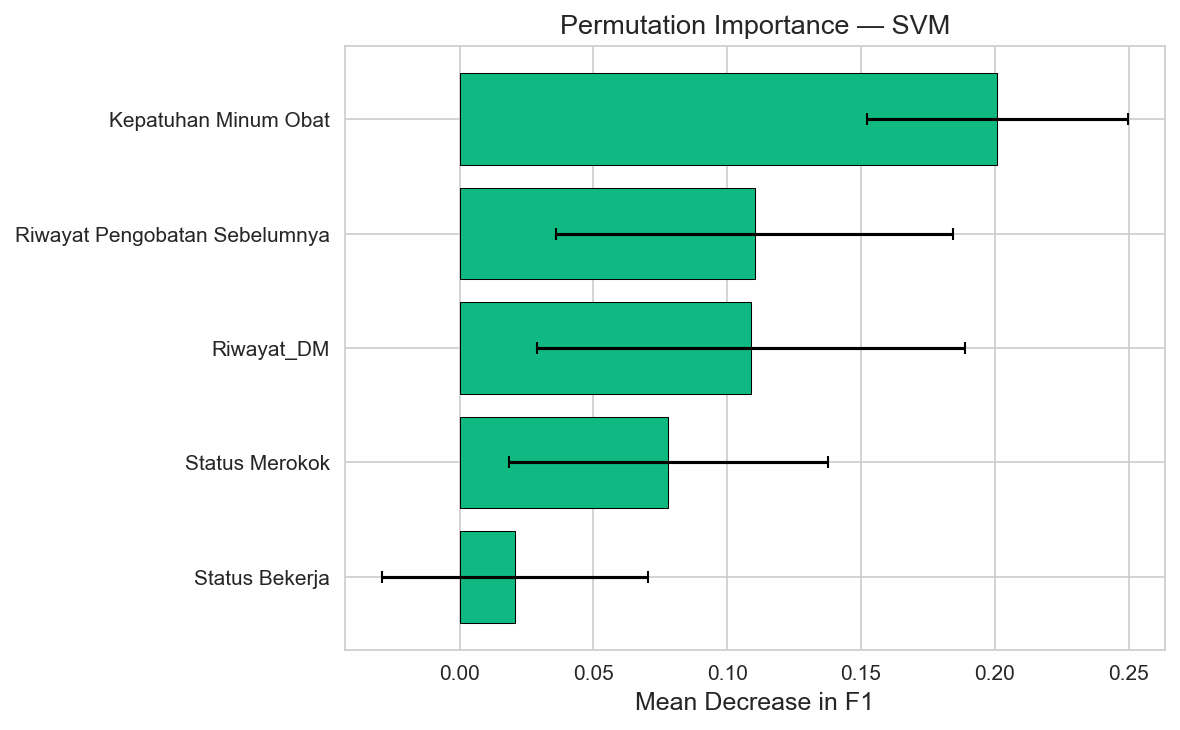

In [18]:
# Permutation Importance for SVM
svm_key = [k for k in interp if 'Support Vector Machine' in k]
if svm_key:
    pi = interp[svm_key[0]].get('permutation_importance', [])
    if pi:
        pi_df = pd.DataFrame(pi).sort_values('importance_mean', ascending=True)
        pi_df = pi_df[pi_df['importance_mean'] > 0]

        if len(pi_df) > 0:
            fig, ax = plt.subplots(figsize=(8, max(5, len(pi_df) * 0.4)))
            ax.barh(pi_df['feature'], pi_df['importance_mean'],
                    xerr=pi_df['importance_std'], color='#10b981',
                    edgecolor='black', linewidth=0.5, capsize=3)
            ax.set_xlabel('Mean Decrease in F1')
            ax.set_title('Permutation Importance \u2014 SVM')
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / 'permutation_importance_svm.png')
            plt.savefig(FIGURES_DIR / 'permutation_importance_svm.pdf')
            plt.show()

## 10. Gini Feature Importance - Decision Tree

Bagian ini melatih Decision Tree khusus dengan `criterion='gini'` pada training set hasil pipeline utama. Pipeline tetap: split 70/15/15 terlebih dahulu, SMOTE hanya pada training set, lalu model Decision Tree Gini dilatih untuk menghitung `feature_importances_` berbasis penurunan impurity Gini.


Gini Feature Importance - Decision Tree
Pipeline: split 70/15/15 -> SMOTE pada training set saja -> Decision Tree criterion=gini
Parameter Decision Tree Gini: {'criterion': 'gini', 'random_state': 42}


,Feature,Gini Importance
7,Riwayat Pengobatan Sebelumnya,0.411565
0,Ket.Usia,0.201652
5,Kepatuhan Minum Obat,0.166264
1,Status Bekerja,0.069780
2,Status Merokok,0.057148
3,Riwayat_DM,0.028919
6,Efek Samping Obat,0.028185
8,Panduan Pengobatan,0.020548
4,Riwayat_HIV,0.015940


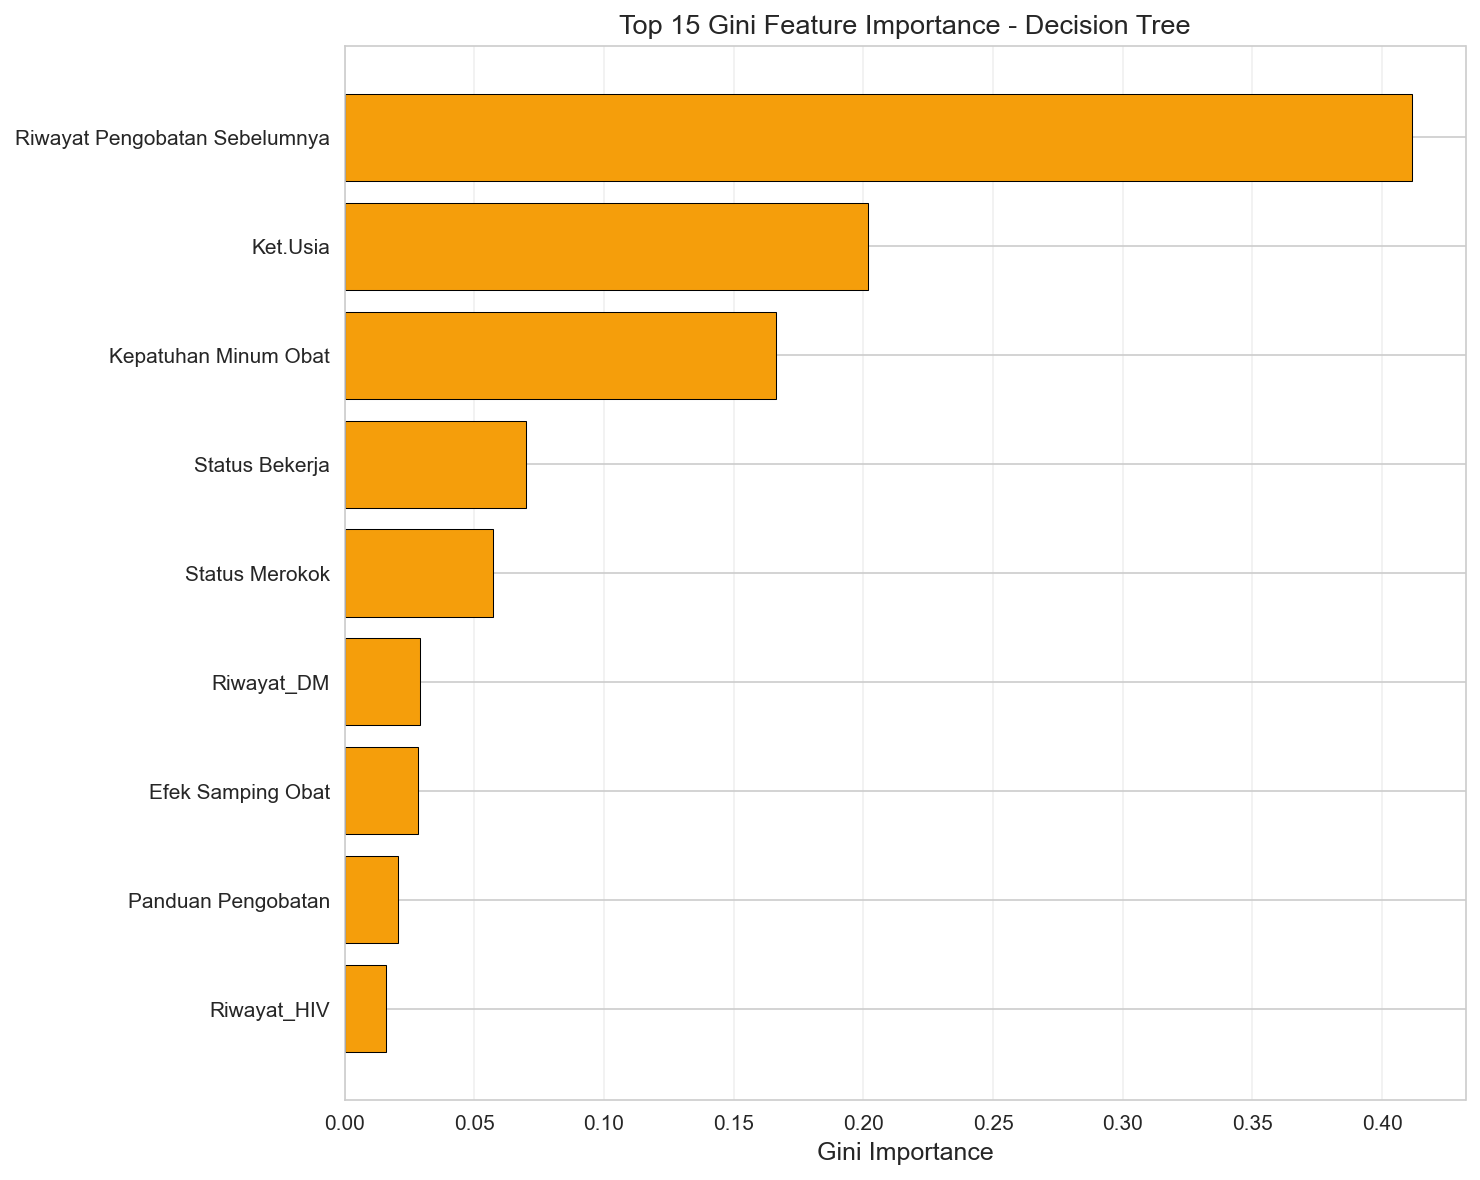

In [19]:
# Gini Feature Importance - Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

best_tree_params = trainer.best_params.get('Decision Tree', {}).get('params', {})
gini_tree_params = {
    key.replace('classifier__', ''): value
    for key, value in best_tree_params.items()
    if key.startswith('classifier__') and key != 'classifier__criterion'
}
gini_tree_params['criterion'] = 'gini'
gini_tree_params['random_state'] = 42

gini_decision_tree_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(**gini_tree_params)),
])
gini_decision_tree_model.fit(X_train, y_train)
gini_classifier = gini_decision_tree_model.named_steps['classifier']

gini_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Gini Importance': gini_classifier.feature_importances_,
}).sort_values('Gini Importance', ascending=False)

print('Gini Feature Importance - Decision Tree')
print('Pipeline: split 70/15/15 -> SMOTE pada training set saja -> Decision Tree criterion=gini')
print(f"Parameter Decision Tree Gini: {gini_tree_params}")
display(gini_importance)

fig, ax = plt.subplots(figsize=(10, 8))
top_gini = gini_importance.head(15).sort_values('Gini Importance')
ax.barh(top_gini['Feature'], top_gini['Gini Importance'], color='#f59e0b', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Gini Importance')
ax.set_title('Top 15 Gini Feature Importance - Decision Tree')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gini_feature_importance_decision_tree.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'gini_feature_importance_decision_tree.pdf', bbox_inches='tight')
plt.show()


## 11. SHAP Interpretability — Support Vector Machine (KernelExplainer exact)

Revisi client: interpretability model utama diganti dari Logistic Regression ke **SVM**.
Karena package `shap` membutuhkan `numba` (tak kompatibel Python 3.14), SHAP SVM dihitung
**secara eksak (native)** dengan semua 2^M koalisi (M = jumlah fitur) — hasil matematis
identik dengan `shap.KernelExplainer` (Lundberg & Lee, 2017).

**Konsistensi web <> notebook:** bagian ini memanggil `run_dca()` (modul `dca.py`) — fungsi
yang **sama persis** dengan yang menampilkan "Kontribusi Setiap Variabel terhadap Prediksi
(SVM)" di halaman *Statistics* web. Karena itu nilai `mean |SHAP|` per fitur di bawah ini
identik dengan tabel di web.

Pipeline: split 70/15/15 (stratify, seed 42) → SMOTE (seed 42) → GridSearchCV SVM RBF/linear
(`C=[0.1,1,10,100]`, `gamma=[scale,auto]`, scoring `f1`, CV stratified 5-fold seed 42).

SHAP:
- Background: `50 sampel acak dari data latih bersih (n=151), seed=42`.
- Kelas output f(x) = P(Berhasil) (`positive_class=0`) — konsisten dengan tampilan web.
- Semua nilai dihitung pada **internal test set (n=23)** hasil split di atas.

Feature Engineering: IMT dihitung dari BB dan TB (175 records)
=== Nilai SHAP (mean |SHAP|) per fitur ===
                        Fitur  Mean |SHAP|  Rank
         Kepatuhan Minum Obat     0.170511     1
Riwayat Pengobatan Sebelumnya     0.134633     2
                   Riwayat_DM     0.044745     3
               Status Merokok     0.044334     4
           Panduan Pengobatan     0.041803     5
            Efek Samping Obat     0.038898     6
               Status Bekerja     0.034847     7
                     Ket.Usia     0.032495     8
                  Riwayat_HIV     0.022143     9

Base value (E_b[f(background)]): 0.4967
Background: 50 sampel acak dari data latih bersih (n=151), seed=42
Jumlah sampel test: 23, fitur: 9


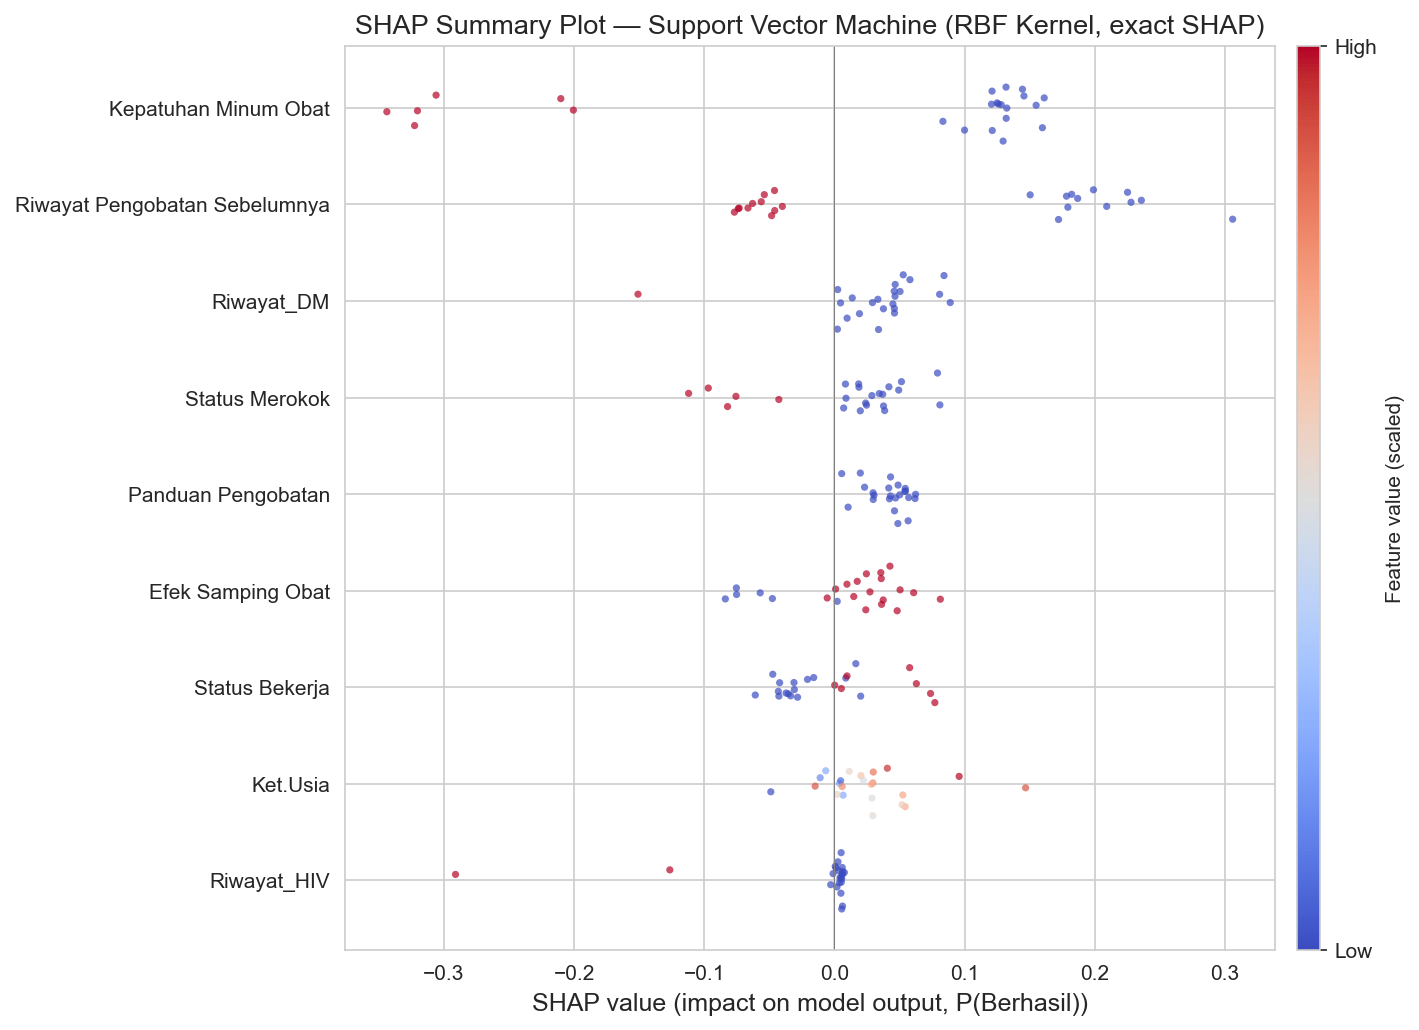

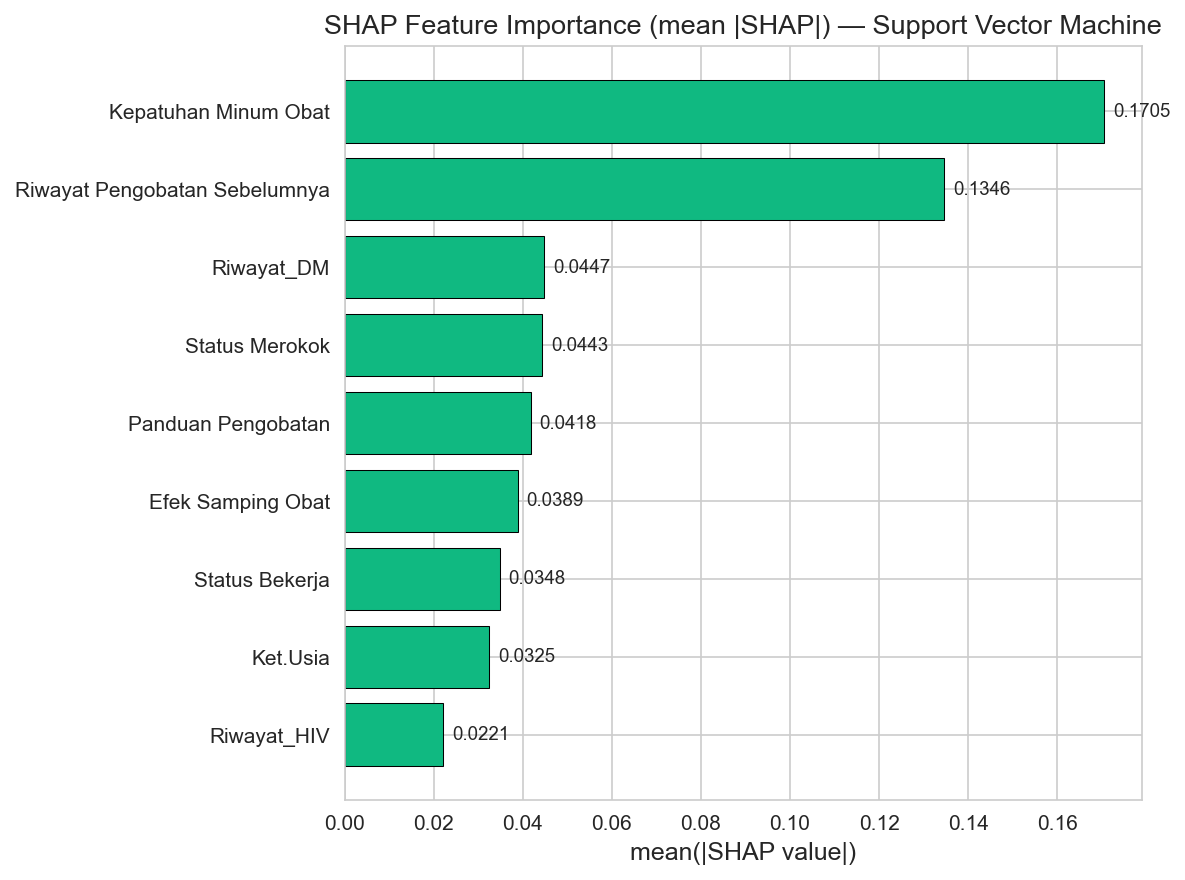

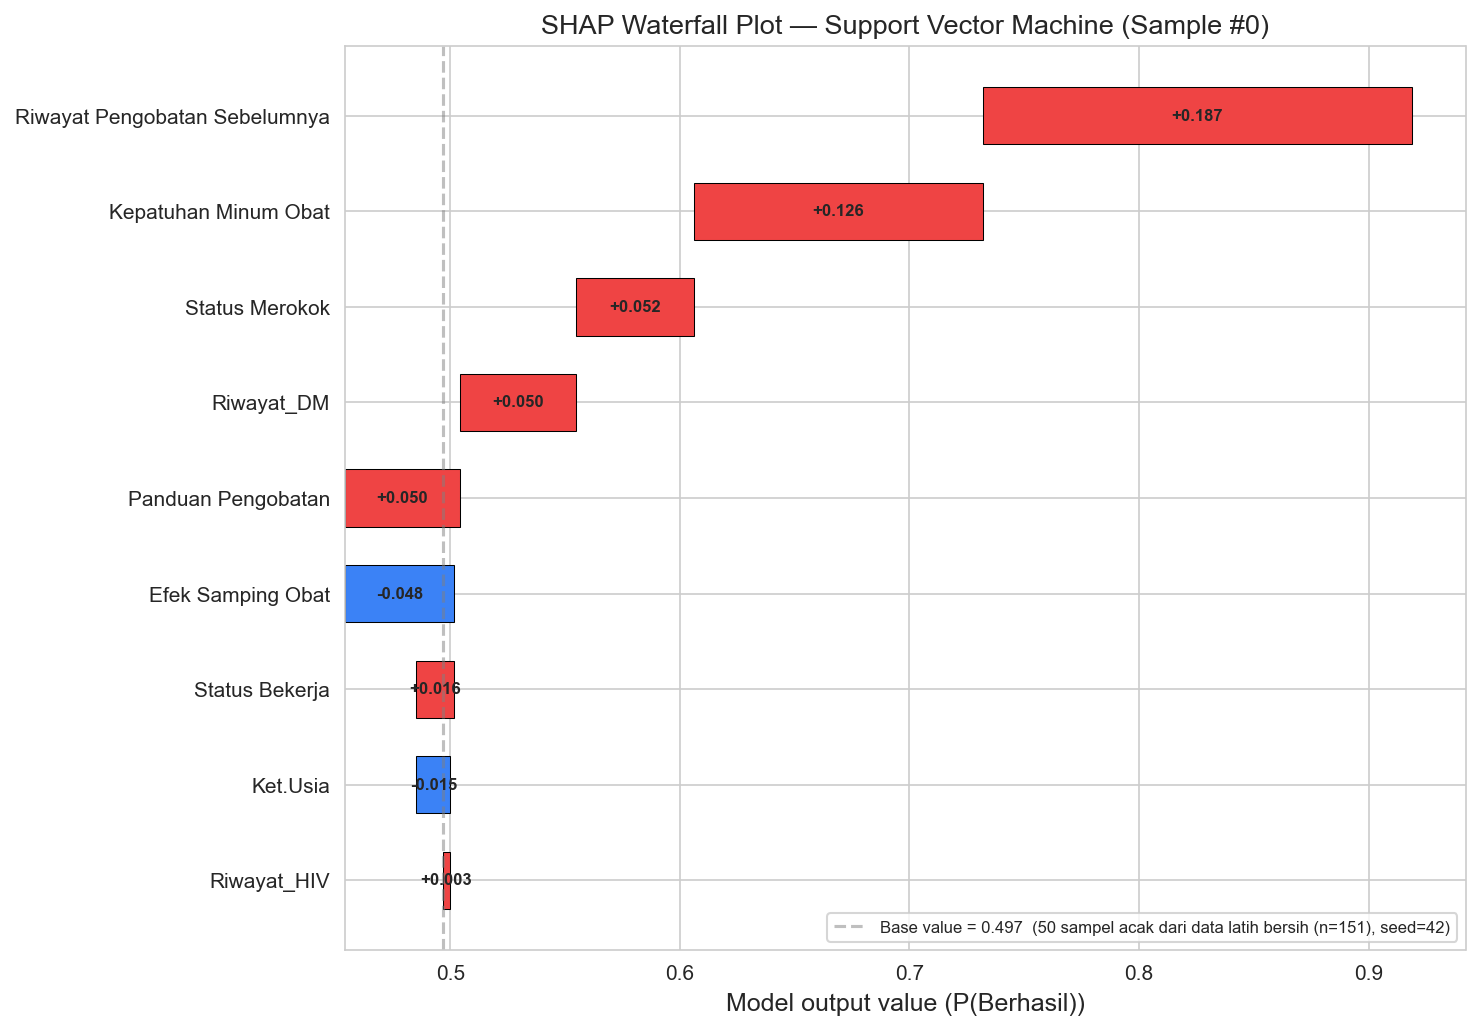

SHAP analysis complete (exact Kernel SHAP). Background: 50 sampel acak dari data latih bersih (n=151), seed=42


In [20]:
from dca import run_dca

# --- Konsistensi web <> notebook: panggil fungsi yang SAMA persis dengan web ---
# run_dca() menghitung: split 70/15/15 (seed 42) -> SMOTE -> GridSearchCV SVM
# (C=[0.1,1,10,100], kernel=[rbf,linear], gamma=[scale,auto], scoring=f1)
# -> SHAP exact (KernelExplainer-equivalent) dengan background 50 sampel acak
# dari data latih bersih (seed=42), f(x) = P(Berhasil).
# Nilai `mean |SHAP|` di sini = nilai yang ditampilkan di halaman Statistics web.
res = run_dca(verbose=False)

contributions = res['contributions']          # [{feature, contribution}] sorted desc
shap_meta = res['shap']
shap_values = np.array(shap_meta['values'])   # (n_test, M)
base_value = shap_meta['base_value']          # E_b[f(background)]
feature_names = shap_meta['feature_names']
X_scaled = np.array(shap_meta['X_test_scaled'])
y_test = np.array(shap_meta['y_test'])
mean_abs_shap = np.array([shap_meta['mean_abs'][f] for f in feature_names])

# --- Tabel numerik SHAP (nilai yang ingin dilihat: mean |SHAP| per fitur) ---
shap_table = pd.DataFrame({
    'Fitur': feature_names,
    'Mean |SHAP|': mean_abs_shap,
    'Rank': np.argsort(np.argsort(-mean_abs_shap)) + 1,
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
print("=== Nilai SHAP (mean |SHAP|) per fitur ===")
print(shap_table.to_string(index=False))
print(f"\nBase value (E_b[f(background)]): {base_value:.4f}")
print(f"Background: {shap_meta['background']}")
print(f"Jumlah sampel test: {len(y_test)}, fitur: {len(feature_names)}")

# Simpan tabel sebagai CSV untuk disertasi
shap_table.to_csv(FIGURES_DIR / 'shap_importance_table.csv', index=False)

# --- 1. Summary Plot (beeswarm, warna = nilai fitur) ---
fig, ax = plt.subplots(figsize=(10, 7))
sorted_idx = np.argsort(mean_abs_shap)
cmap = plt.cm.coolwarm
for pos, idx in enumerate(sorted_idx):
    vals = shap_values[:, idx]
    feat_vals = X_scaled[:, idx]
    norm_feat = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-10)
    colors_arr = cmap(norm_feat)
    jitter = np.random.normal(0, 0.12, size=len(vals))
    ax.scatter(vals, [pos] * len(vals) + jitter, c=colors_arr, s=12, alpha=0.7, edgecolors='none')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('SHAP value (impact on model output, P(Berhasil))')
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_title('SHAP Summary Plot \u2014 Support Vector Machine (RBF Kernel, exact SHAP)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=40)
cbar.set_label('Feature value (scaled)', fontsize=10)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary_svm.png')
plt.savefig(FIGURES_DIR / 'shap_summary_svm.pdf')
plt.show()

# --- 2. Bar Plot (mean |SHAP|) ---
fig, ax = plt.subplots(figsize=(8, 6))
sorted_idx_bar = np.argsort(mean_abs_shap)
ax.barh([feature_names[i] for i in sorted_idx_bar],
        mean_abs_shap[sorted_idx_bar],
        color='#10b981', edgecolor='black', linewidth=0.5)
for i, val in enumerate(mean_abs_shap[sorted_idx_bar]):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('mean(|SHAP value|)')
ax.set_title('SHAP Feature Importance (mean |SHAP|) \u2014 Support Vector Machine')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar_svm.png')
plt.savefig(FIGURES_DIR / 'shap_bar_svm.pdf')
plt.show()

# --- 3. Waterfall Plot untuk sampel test pertama ---
sample_idx = 0
sample_shap = shap_values[sample_idx]
sorted_wf = np.argsort(np.abs(sample_shap))
top_n = min(15, len(feature_names))
top_idx = sorted_wf[-top_n:]

fig, ax = plt.subplots(figsize=(10, 7))
cumulative = base_value
y_positions, y_labels, lefts, widths, colors_wf = [], [], [], [], []
for rank, fi in enumerate(top_idx):
    y_positions.append(rank)
    y_labels.append(feature_names[fi])
    val = sample_shap[fi]
    lefts.append(cumulative if val > 0 else cumulative + val)
    widths.append(abs(val))
    colors_wf.append('#ef4444' if val > 0 else '#3b82f6')
    cumulative += val

ax.barh(y_positions, widths, left=lefts, color=colors_wf,
        edgecolor='black', linewidth=0.5, height=0.6)
for i, (l, w, val_idx) in enumerate(zip(lefts, widths, top_idx)):
    val = sample_shap[val_idx]
    ax.text(l + w / 2, i, f'{val:+.3f}', ha='center', va='center', fontsize=8, fontweight='bold')
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)
ax.axvline(x=base_value, color='gray', linestyle='--', alpha=0.5,
           label=f'Base value = {base_value:.3f}  ({shap_meta["background"]})')
ax.set_xlabel('Model output value (P(Berhasil))')
ax.set_title('SHAP Waterfall Plot \u2014 Support Vector Machine (Sample #0)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_waterfall_svm.png')
plt.savefig(FIGURES_DIR / 'shap_waterfall_svm.pdf')
plt.show()

print(f"SHAP analysis complete (exact Kernel SHAP). Background: {shap_meta['background']}")

## 11b. Decision Curve Analysis (DCA) — SVM

Revisi client #1: tambahan **Decision Curve Analysis (DCA)** (Vickers & Elkin, 2006) dan
**kontribusi per variabel** terhadap prediksi. Net benefit dihitung pada data internal test:

$$\text{Net Benefit}(p_t) = \frac{\text{TP}}{n} - \frac{\text{FP}}{n} \cdot \frac{p_t}{1-p_t}$$

Kontribusi per variabel diambil dari `mean |SHAP|` SVM (exact Kernel SHAP) pada test set —
nilai yang sama persis dengan tabel "Kontribusi Setiap Variabel terhadap Prediksi (SVM)"
di halaman *Statistics* web, karena keduanya memanggil `run_dca()` pada modul yang sama.
Model & split identik: 9 fitur terpilih, internal test n=23, seed 42, f(x) = P(Berhasil).

Feature Engineering: IMT dihitung dari BB dan TB (175 records)
=== Decision Curve Analysis ===
Prevalence: 0.304 (n=23)
AUC-ROC (test): 0.982
Kontribusi per variabel: [{'feature': 'Kepatuhan Minum Obat', 'contribution': 0.17051107978179308}, {'feature': 'Riwayat Pengobatan Sebelumnya', 'contribution': 0.1346332277072722}, {'feature': 'Riwayat_DM', 'contribution': 0.04474484235903149}, {'feature': 'Status Merokok', 'contribution': 0.04433413961499408}, {'feature': 'Panduan Pengobatan', 'contribution': 0.04180333269641016}, {'feature': 'Efek Samping Obat', 'contribution': 0.038898411767988764}, {'feature': 'Status Bekerja', 'contribution': 0.03484718901548348}, {'feature': 'Ket.Usia', 'contribution': 0.03249532698406793}, {'feature': 'Riwayat_HIV', 'contribution': 0.022143123037559078}]

Kontribusi per variabel (mean |SHAP|):
  Kepatuhan Minum Obat                0.1705
  Riwayat Pengobatan Sebelumnya       0.1346
  Riwayat_DM                          0.0447
  Status Merokok             

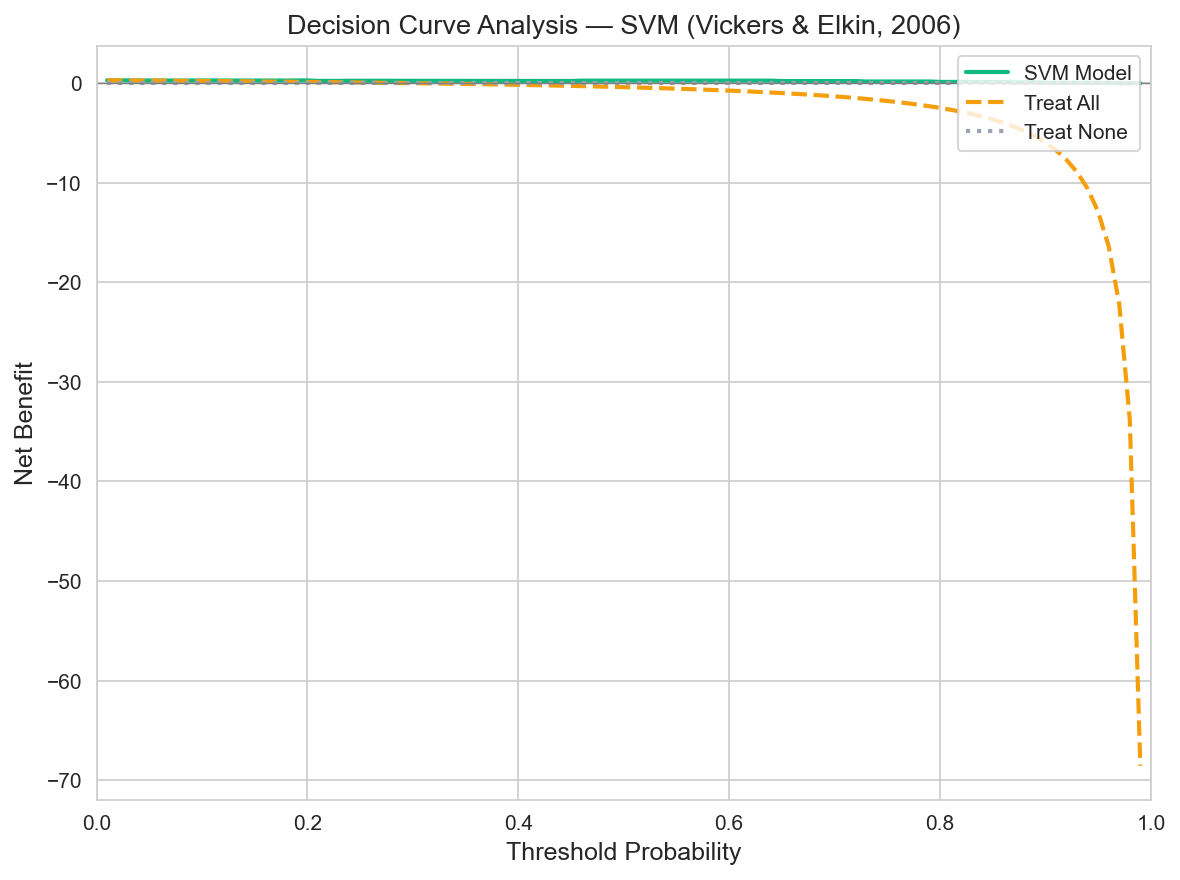

In [21]:
from dca import run_dca
from external_validation import save_metrics_csv

dca_res = run_dca(verbose=True)
print('\nKontribusi per variabel (mean |SHAP|):')
if dca_res.get('contributions'):
    for c in dca_res['contributions']:
        print(f"  {c['feature']:35s} {c['contribution']:.4f}")

# --- Figure DCA ---
fig, ax = plt.subplots(figsize=(8, 6))
curve = dca_res['curve']
ax.plot(curve['thresholds'], curve['net_benefit_model'], color='#10b981',
        linewidth=2, label='SVM Model')
ax.plot(curve['thresholds'], curve['net_benefit_all'], color='#f59e0b',
        linestyle='--', linewidth=2, label='Treat All')
ax.plot(curve['thresholds'], curve['net_benefit_none'], color='#9ca3af',
        linestyle=':', linewidth=2, label='Treat None')
ax.axhline(0, color='gray', linewidth=0.7)
ax.set_xlabel('Threshold Probability')
ax.set_ylabel('Net Benefit')
ax.set_title('Decision Curve Analysis \u2014 SVM (Vickers & Elkin, 2006)')
ax.legend(loc='upper right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dca_curve.png')
plt.savefig(FIGURES_DIR / 'dca_curve.pdf')
plt.show()


## 11c. External Validation — Kohort Kab. Gowa (Register TBC.03) — Skenario 3

Revisi client #2: validasi model pada kohort pasien **Kab. Gowa, Sulawesi Selatan**
(Register TBC.03, Januari 2024 – Agustus 2026).

Data Gowa disusun ulang mengikuti **format model produksi web** (19 kolom, identik dengan
Data Uji ML Makassar) sehingga **seluruh 9 fitur model web tersedia**: `Ket.Usia`,
`Status Bekerja`, `Status Merokok`, `Riwayat_DM`, `Riwayat_HIV`, `Kepatuhan Minum Obat`,
`Efek Samping Obat`, `Riwayat Pengobatan Sebelumnya`, `Panduan Pengobatan`.
Satu-satunya kolom yang kosong adalah `Efek_Samping_Obat` (underscore), yang bukan fitur model.

**Skenario 3 (augmentasi data latih):** karena performa model yang hanya dilatih pada
data internal menurun tajam terhadap data Gowa (covariate shift), data latih digabungkan
menjadi **internal (Makassar) + Gowa** (196 baris). Model **SVM 9 fitur** dilatih ulang pada
data gabungan (split 70/15/15 + SMOTE + tuning), dievaluasi pada holdout internal dan
seluruh Gowa. Catatan: karena Gowa ikut data latih, angka eksternal merefleksikan
**augmentasi data latih**, bukan validasi eksternal murni.

Tabel berikut membandingkan metrik validasi internal vs eksternal.


In [22]:
from external_validation import run_external_validation

ev = run_external_validation(verbose=True)

# --- Perbandingan Metrik: internal vs eksternal ---
rows = ev['table6']['rows']
print('\n=== Perbandingan Metrik: Validasi Internal vs Eksternal (Skenario 3) ===')
print(f"{'Metrik':<14}{'Internal (Test)':>18}{'Eksternal (Gowa)':>18}")
for r in rows:
    dp = 4 if r['metric'] == 'Brier score' else 2
    print(f"{r['metric']:<14}{r['internal_test']:>18.{dp}f}{r['external_test']:>18.{dp}f}")

Feature Engineering: IMT dihitung dari BB dan TB (175 records)
=== External Validation (Kohort Gowa) — Skenario 3: data latih gabungan ===
Model: Support Vector Machine (external 9-fiturs) | params={'C': '100', 'gamma': 'auto', 'kernel': 'rbf'} | SMOTE=True
Internal test: {'accuracy': 86.67, 'precision': 83.33, 'recall': 62.5, 'f1': 71.43, 'specificity': 95.45, 'ppv': 83.33, 'npv': 87.5, 'n': 30, 'confusion_matrix': {'tp': 5, 'tn': 21, 'fp': 1, 'fn': 3}, 'auc_roc': 93.75, 'brier': 0.0965}
External test: {'accuracy': 84.44, 'precision': 56.25, 'recall': 100.0, 'f1': 72.0, 'specificity': 80.56, 'ppv': 56.25, 'npv': 100.0, 'n': 45, 'confusion_matrix': {'tp': 9, 'tn': 29, 'fp': 7, 'fn': 0}, 'auc_roc': 93.21, 'brier': 0.1236}
ROC AUC eksternal: 93.21

=== Perbandingan Metrik: Validasi Internal vs Eksternal (Skenario 3) ===
Metrik           Internal (Test)  Eksternal (Gowa)
Accuracy                   86.67             84.44
Precision                  83.33             56.25
Recall           

## 12. Nested Cross-Validation


In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Nested CV: outer=5 folds, inner=3 folds
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
        'params': {'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}
    },
    'Decision Tree': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('classifier', DecisionTreeClassifier(random_state=42))]),
        'params': {'classifier__max_depth': [3, 5, 7, 10, None], 'classifier__min_samples_split': [2, 5, 10]}
    },
    'SVM': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('classifier', SVC(probability=True, class_weight='balanced', random_state=42))]),
        'params': {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['rbf', 'linear']}
    },
}

nested_results = {}
for name, cfg in models_config.items():
    print(f"\nNested CV for {name}...")
    inner_search = GridSearchCV(cfg['pipeline'], cfg['params'], cv=inner_cv, scoring='f1', n_jobs=1)
    outer_scores = cross_val_score(inner_search, X, y, cv=outer_cv, scoring='f1', n_jobs=1)
    nested_results[name] = {
        'mean': outer_scores.mean(),
        'std': outer_scores.std(),
        'scores': outer_scores.tolist()
    }
    print(f"  F1 = {outer_scores.mean():.4f} +/- {outer_scores.std():.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in outer_scores]}")

print("\n=== Nested CV Summary ===")
nested_df = pd.DataFrame([
    {'Model': n, 'F1 (mean+/-std)': f"{r['mean']*100:.2f}% +/- {r['std']*100:.2f}%"}
    for n, r in nested_results.items()
])
nested_df


Nested CV for Logistic Regression...
  F1 = 0.8358 +/- 0.1154
  Fold scores: ['0.8333', '0.6154', '0.9412', '0.8889', '0.9000']

Nested CV for Decision Tree...
  F1 = 0.8071 +/- 0.1229
  Fold scores: ['0.8000', '0.5714', '0.8750', '0.8889', '0.9000']

Nested CV for SVM...
  F1 = 0.7999 +/- 0.1007
  Fold scores: ['0.7826', '0.6154', '0.8889', '0.8235', '0.8889']

=== Nested CV Summary ===


,Model,F1 (mean+/-std)
0,Logistic Regression,83.58% +/- 11.54%
1,Decision Tree,80.71% +/- 12.29%
2,SVM,79.99% +/- 10.07%


## 13. Sensitivity Analysis


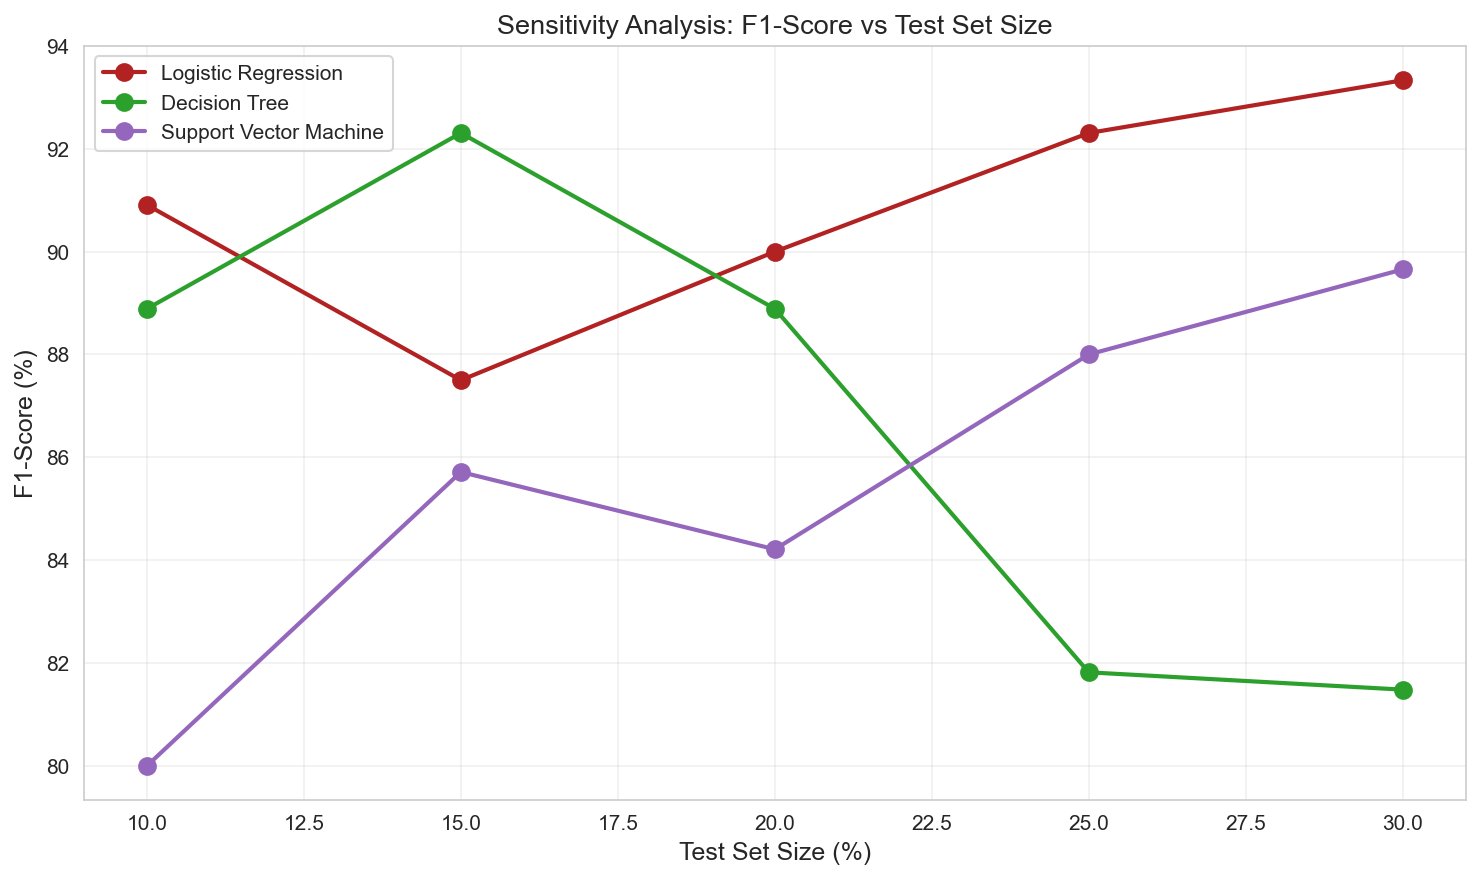


=== Class Distribution ===
Original dataset: {0: 105, 1: 46} (total: 151)
Training set: {0: 73, 1: 32} (total: 105)
Training set size: 105
Validation set size: 23
Test set size: 23

=== SMOTE Applied ===
Training set after SMOTE: {0: 73, 1: 73} (total: 146)

=== Hybrid Feature Selection ===
Selected features (9): ['Ket.Usia', 'Status Bekerja', 'Status Merokok', 'Riwayat_DM', 'Riwayat_HIV', 'Kepatuhan Minum Obat', 'Efek Samping Obat', 'Riwayat Pengobatan Sebelumnya', 'Panduan Pengobatan']

=== Hyperparameter Tuning ===

Tuning Logistic Regression...
  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1: 0.9087

Tuning Decision Tree...
  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1: 0.8770

Tuning Support Vector Machine...
  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1: 0.9172

=== Cross Validation ===

Cross-validating Logistic Regression...
  Accuracy: 0.9106 (+/- 0.0519

In [24]:
# Test with different train/test ratios
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

ratios = [0.1, 0.15, 0.2, 0.25, 0.3]
sensitivity_results = {name: [] for name in trainer.models}

for test_ratio in ratios:
    X_tr, X_ts, y_tr, y_ts = train_test_split(
        X, y, test_size=test_ratio, random_state=42, stratify=y
    )
    for name, model in trainer.models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_ts)
        f1 = f1_score(y_ts, y_pred, zero_division=0)
        sensitivity_results[name].append(f1)

fig, ax = plt.subplots(figsize=(10, 6))
for name, scores in sensitivity_results.items():
    ax.plot([r*100 for r in ratios], [s*100 for s in scores], 'o-',
            label=name, color=model_colors.get(name, None), linewidth=2, markersize=8)

ax.set_xlabel('Test Set Size (%)')
ax.set_ylabel('F1-Score (%)')
ax.set_title('Sensitivity Analysis: F1-Score vs Test Set Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensitivity_analysis.png')
plt.savefig(FIGURES_DIR / 'sensitivity_analysis.pdf')
plt.show()

# Re-train with original split to restore model state (dengan SMOTE, sesuai web)
training_results = trainer.train(X, y, use_smote=True)
print("Models re-trained with original split (SMOTE enabled).")

## 14. Export All Figures \u2014 Summary


In [25]:
# List all generated figures
import glob
figures = sorted(glob.glob(str(FIGURES_DIR / '*')))
print(f"Total figures generated: {len(figures)}")
print()
for f in figures:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):45s} {size_kb:7.1f} KB")

print(f"\nAll figures saved to: {FIGURES_DIR.resolve()}")
print("PNG files are suitable for Word/PowerPoint embedding.")
print("PDF files are suitable for LaTeX embedding.")

Total figures generated: 58

  bootstrap_ci.pdf                                 20.4 KB
  bootstrap_ci.png                                229.1 KB
  calibration_curves.pdf                           18.3 KB
  calibration_curves.png                          284.4 KB
  class_distribution.pdf                           16.0 KB
  class_distribution.png                          127.3 KB
  confusion_matrices.pdf                           17.8 KB
  confusion_matrices.png                          125.3 KB
  dca_curve.pdf                                    19.9 KB
  dca_curve.png                                   119.0 KB
  eda_correlation_heatmap.pdf                      31.5 KB
  eda_correlation_heatmap.png                     578.3 KB
  external_roc_gowa.pdf                            18.1 KB
  external_roc_gowa.png                           128.8 KB
  external_validation_table.csv                     0.1 KB
  feature_importance_dt.pdf                        17.8 KB
  feature_importance_dt.png